# Investigate the similarities between the templates for CUT3 (bdt_dc > 0.5)

### Setting up the data and tools

In [3]:
# Importing the notebook with common setup 
%run 'bdt-all-common.ipynb'

Welcome to JupyROOT 6.28/00


Invoke (root_datasets, pandas_datasets) = load_data(inclmc_type="23903000") to load datasets
Invoke (root_datasets, pandas_datasets) = load_data(inclmc_type="23903003") to load dataset for double charm
Invoke  df_signal_23903000 = load_signal_from_inclMC() to load signal from 23903000 Inclusive MC
or
Invoke  df_signal = load_signal_all()
Invoke  df_background = load_background_category(category)


In [4]:
import seaborn as sn
plt.rcParams["figure.figsize"] = (15, 15)

## Applying  CUT3 i.e. BDT_dc > 0.5

In [5]:
bdt_cutval=0.5

In [6]:
dfcut = df.query(f"bdt_dc > {bdt_cutval}")
c = mygroupby(dfcut, 'category')
import categories4 as f
c['name'] = c.apply(lambda row: categories[f"{row['category']:.4g}"], axis=1)
c['simplified_name'] = c.apply(lambda row: f.detailed_to_simplified_category_mapping.get(row['name'], 'NA'), axis=1)
c

,category,count,Percentage,cumulative %,name,simplified_name
0,19,18937,26.312352,26.312352,Xc_signal_Ypis_displaced_fromB0_fromDp,doubleCharm
1,18,7437,10.333472,36.645825,Xc_signal_Ypis_displaced_fromBs_fromDs,doubleCharm
2,14,7106,9.873558,46.519383,Xc_signal_Ypis_diffVertex_doubleCharm_OneFromB,doubleCharm
3,22,6482,9.006530,55.525914,Xc_signal_Ypis_displaced_fromBs_fromDp,doubleCharm
4,20,6392,8.881478,64.407392,Xc_signal_Ypis_displaced_fromBp_fromD0,doubleCharm
5,0,6134,8.522996,72.930388,Xc_background,Xc_background
6,24,5065,7.037655,79.968042,Xc_signal_Ypis_displaced_fromBs_fromTau,signal
7,7,3376,4.690843,84.658886,Xc_signal_Ypis_nomatch_doubleCharm,doubleCharm
8,23,3333,4.631096,89.289982,Xc_signal_Ypis_displaced_fromBp_fromDp,doubleCharm
9,25,1617,2.246769,91.536751,Xc_signal_Ypis_displaced_fromB0_fromD0,doubleCharm


There are 23 categories represented by more than 100 candidates

## Using the Kolmogorov-Smirnov test to see which distributions are similar

In [7]:
def find_clusters(m, threshold):
    allsets = set()
    for i in m.index:
        s = frozenset(m[m[i] > threshold][i].index)
        if s:
            allsets.add(s)
    return allsets

# Iterative
def merge_clusters(clusters):
    final = []
    tomerge = list(clusters)
    while True:
        h = tomerge[0]
        t = tomerge[1:]
        if not t:
            final.append(h)
            break
        tmp = []
        merged = False
        for c in t:
            if h & c:
                tmp.append( h | c)
                merged = True
            else:
                tmp.append(c)
        if not merged:
            final.append(h)
        tomerge = tmp
    return final

def merge_clusters_rec(unmerged, merged):
    """ Merge sets with non null intersection """
    h = unmerged[0]
    t = unmerged[1:]
    
    # End of recursion if ony one element in the list,nothing to merge to....
    if not t:
        merged.append(h)
        return t, merged
    
    # Iterate over the list of elements, comparing the first one h,
    # with all the others. If h has no intersection we add it to the
    # list of processed elements (merged), otherwise we merge it to the
    # element in common and we iterate the function again on the 
    # new list containing this new element plus the others
    tmp = []
    was_merged = False
    for c in t:
        if h & c:
            tmp.append( h | c)
            was_merged = True
        else:
            tmp.append(c)
    if not was_merged:
        merged.append(h)

    return merge_clusters_rec(tmp, merged)


def find_and_merge_clusters(m, threshold=0.5):
    clusters = find_clusters(m, threshold)
    unmerged, merged = merge_clusters_rec(list(clusters), [])
    return [ list(s) for s in merged ]


In [8]:
from scipy.stats import ks_2samp

def similar_categories(df, shown_number):
    """ Finding which categories have similar histograms for q2_2, tauY_2, bdt_all """
    
    # Grouping the samples per category
    c = mygroupby(df, 'category')
    c['name'] = c.apply(lambda row: categories[f"{row['category']:.4g}"], axis=1)
    
    # Preparing the list of categories to process
    #shown_number=17
    shown_categs = list(c.head(shown_number)['category'])
  
    # Building a list of detasets filtered 
    datasets = { f"{c}":  df.query(f"category == {c}") for c in shown_categs }
    datasets["others"] =  df.query(f"category not in {shown_categs}")
    datasets_names = [ f"{c}:" + categories[f"{c}"] for c in shown_categs]
    datasets_names.append("others")
    
    # List of column names
    cols = np.array([ str(c) for c in shown_categs ] + [ "others" ])

    # Preparing the matrix with the final results
    stats= pd.DataFrame(np.zeros((shown_number +1, shown_number + 1)), columns=cols)
    stats["name"] = cols.T
    stats = stats.set_index("name", drop=True).copy()

    stats_q2_2 = stats.copy()
    stats_tauY_2 = stats.copy()
    stats_bdt_all = stats.copy()
    print(cols)

    for i in range(len(cols)):
        for j in range(len(cols)):
            # Only deal with half the matrix
            if j > i:
                continue
            
            todo = { "q2_2": stats_q2_2,
                     "tauY_2": stats_tauY_2,
                     "bdt_dc": stats_bdt_all,
                   }
            for myvar, matrix in todo.items():
                res = ks_2samp(datasets[cols[i]][myvar], datasets[cols[j]][myvar], alternative='two-sided', method='exact')
                print(res)
                print(res[1])
                matrix[cols[i]][cols[j]] = res[1]
                matrix[cols[j]][cols[i]] = matrix[cols[i]][cols[j]] 
    return stats_q2_2, stats_tauY_2, stats_bdt_all

In [9]:
shown_number=23
sq2_2, stauY_2, sbdt_all = similar_categories(dfcut, shown_number)

['19' '18' '14' '22' '20' '0' '24' '7' '23' '25' '16' '21' '26' '13' '29'
 '27' '15' '28' '8' '2' '6' '30' '31' 'others']
KstestResult(statistic=0.0, pvalue=1.0, statistic_location=0.00896590686416626, statistic_sign=1)
1.0
KstestResult(statistic=0.0, pvalue=1.0, statistic_location=8.063009128529359e-05, statistic_sign=1)
1.0
KstestResult(statistic=0.0, pvalue=1.0, statistic_location=0.50000197, statistic_sign=1)
1.0
KstestResult(statistic=0.28710178898036676, pvalue=2.2604e-320, statistic_location=6.811073288623094, statistic_sign=1)
2.2604e-320
KstestResult(statistic=0.167719288947651, pvalue=1.3115287003919956e-131, statistic_location=0.0008784302449142232, statistic_sign=1)
1.3115287003919956e-131
KstestResult(statistic=0.11350317229512898, pvalue=2.3583896360142791e-60, statistic_location=0.68464416, statistic_sign=1)
2.3583896360142791e-60
KstestResult(statistic=0.0, pvalue=1.0, statistic_location=0.0023695418663024904, statistic_sign=1)
1.0
KstestResult(statistic=0.0, pvalue=1.0

KstestResult(statistic=0.17187672889079242, pvalue=1.3793924241568653e-103, statistic_location=6.114787586385249, statistic_sign=-1)
1.3793924241568653e-103
KstestResult(statistic=0.3757189279504791, pvalue=1.5953e-320, statistic_location=0.000677226888504627, statistic_sign=1)
1.5953e-320
KstestResult(statistic=0.36239943729874624, pvalue=1.761e-320, statistic_location=0.7319301, statistic_sign=-1)
1.761e-320
KstestResult(statistic=0.4526836482723386, pvalue=3.88e-321, statistic_location=6.7491750634851435, statistic_sign=-1)
3.88e-321
KstestResult(statistic=0.2218551860637582, pvalue=2.119798024176052e-130, statistic_location=0.0005945327110128403, statistic_sign=1)
2.119798024176052e-130
KstestResult(statistic=0.4636301961816541, pvalue=3.167e-321, statistic_location=0.70928764, statistic_sign=-1)
3.167e-321
KstestResult(statistic=0.09879328370919116, pvalue=1.429647935593929e-25, statistic_location=7.804727266953466, statistic_sign=-1)
1.429647935593929e-25
KstestResult(statistic=0

KstestResult(statistic=0.26255780126431294, pvalue=2.1595724434626368e-131, statistic_location=0.0007489902887824979, statistic_sign=-1)
2.1595724434626368e-131
KstestResult(statistic=0.05185994634677032, pvalue=1.719161861416489e-05, statistic_location=0.72056895, statistic_sign=-1)
1.719161861416489e-05
KstestResult(statistic=0.22377967313019553, pvalue=1.0836279099673488e-88, statistic_location=7.467991633060454, statistic_sign=-1)
1.0836279099673488e-88
KstestResult(statistic=0.45355846542206046, pvalue=5.01e-321, statistic_location=0.0007021330810526184, statistic_sign=-1)
5.01e-321
KstestResult(statistic=0.29449446425392783, pvalue=3.0033609820669586e-154, statistic_location=0.75116897, statistic_sign=1)
3.0033609820669586e-154
KstestResult(statistic=0.30284776107942546, pvalue=2.904256175948817e-136, statistic_location=6.538658509571074, statistic_sign=-1)
2.904256175948817e-136
KstestResult(statistic=0.2242670949559411, pvalue=2.0963956248614783e-74, statistic_location=0.000940

KstestResult(statistic=0.22793958094822633, pvalue=2.1538524034630524e-35, statistic_location=6.40192474579239, statistic_sign=1)
2.1538524034630524e-35
KstestResult(statistic=0.47553132823893585, pvalue=5.321629213856985e-159, statistic_location=0.0005528569442577919, statistic_sign=1)
5.321629213856985e-159
KstestResult(statistic=0.034661055686924395, pvalue=0.30967544920577433, statistic_location=0.73447573, statistic_sign=1)
0.30967544920577433
KstestResult(statistic=0.09436000168036349, pvalue=4.961792933340926e-06, statistic_location=7.517062225719213, statistic_sign=-1)
4.961792933340926e-06
KstestResult(statistic=0.3510616742325201, pvalue=1.2499747715004818e-79, statistic_location=0.0004592283044539027, statistic_sign=1)
1.2499747715004818e-79
KstestResult(statistic=0.1130290761931804, pvalue=1.8152147544555202e-08, statistic_location=0.66583264, statistic_sign=-1)
1.8152147544555202e-08
KstestResult(statistic=0.3307523534108522, pvalue=3.3993038022958274e-70, statistic_locati

KstestResult(statistic=0.3924607409878538, pvalue=1.7789985685599093e-89, statistic_location=0.0007556741413194712, statistic_sign=-1)
1.7789985685599093e-89
KstestResult(statistic=0.02853177843215547, pvalue=0.6599927314105835, statistic_location=0.6915688, statistic_sign=1)
0.6599927314105835
KstestResult(statistic=0.412516305626243, pvalue=2.673162518688552e-98, statistic_location=7.434250570531844, statistic_sign=1)
2.673162518688552e-98
KstestResult(statistic=0.04748717698057989, pvalue=0.10894735572004104, statistic_location=0.002213421057055967, statistic_sign=-1)
0.10894735572004104
KstestResult(statistic=0.17506972850941374, pvalue=1.4928636325195317e-17, statistic_location=0.6915688, statistic_sign=1)
1.4928636325195317e-17
KstestResult(statistic=0.10340387471609667, pvalue=2.214150540064293e-06, statistic_location=8.322545544898988, statistic_sign=-1)
2.214150540064293e-06
KstestResult(statistic=0.2003589617856833, pvalue=7.317274627935951e-23, statistic_location=0.000762099

KstestResult(statistic=0.682352121468071, pvalue=6.951584898483625e-241, statistic_location=6.815557136181355, statistic_sign=1)
6.951584898483625e-241
KstestResult(statistic=0.22360482493747005, pvalue=8.057709591394904e-24, statistic_location=0.0011513988032663426, statistic_sign=1)
8.057709591394904e-24
KstestResult(statistic=0.028895306592270603, pvalue=0.7530802060992156, statistic_location=0.73466855, statistic_sign=1)
0.7530802060992156
KstestResult(statistic=0.43696858321096643, pvalue=8.944539648745404e-79, statistic_location=6.228103682491302, statistic_sign=1)
8.944539648745404e-79
KstestResult(statistic=0.06265479048146617, pvalue=0.053374238522437764, statistic_location=0.0006934395441441791, statistic_sign=1)
0.053374238522437764
KstestResult(statistic=0.13660250830189896, pvalue=7.218386285541414e-08, statistic_location=0.67003286, statistic_sign=-1)
7.218386285541414e-08
KstestResult(statistic=0.46950219301566154, pvalue=6.399515118065596e-76, statistic_location=6.94989

KstestResult(statistic=0.14834666521557743, pvalue=9.413618425289658e-07, statistic_location=0.6595164, statistic_sign=-1)
9.413618425289658e-07
KstestResult(statistic=0.1657745141123602, pvalue=2.5889830644568866e-08, statistic_location=6.7827393674945835, statistic_sign=-1)
2.5889830644568866e-08
KstestResult(statistic=0.196287738100301, pvalue=1.6858934335896536e-11, statistic_location=0.0005959854708608529, statistic_sign=1)
1.6858934335896536e-11
KstestResult(statistic=0.07529947122949773, pvalue=0.04662856558734174, statistic_location=0.7459452, statistic_sign=-1)
0.04662856558734174
KstestResult(statistic=0.22494527662131422, pvalue=7.785372275144903e-15, statistic_location=7.596566241649149, statistic_sign=-1)
7.785372275144903e-15
KstestResult(statistic=0.037601041532540735, pvalue=0.7355019794628717, statistic_location=0.00027118232463713273, statistic_sign=-1)
0.7355019794628717
KstestResult(statistic=0.2984934975750032, pvalue=5.510930471786277e-26, statistic_location=0.775

KstestResult(statistic=0.17183172495989918, pvalue=4.137980594221828e-06, statistic_location=0.0007671467451708094, statistic_sign=1)
4.137980594221828e-06
KstestResult(statistic=0.12111103332148966, pvalue=0.002992910421660914, statistic_location=0.66205704, statistic_sign=1)
0.002992910421660914
KstestResult(statistic=0.4273198030880208, pvalue=4.7675819525558345e-36, statistic_location=7.1701874814982425, statistic_sign=-1)
4.7675819525558345e-36
KstestResult(statistic=0.07085399710509456, pvalue=0.22050543895196975, statistic_location=0.0002060159680899365, statistic_sign=1)
0.22050543895196975
KstestResult(statistic=0.04760348921894137, pvalue=0.696686094843396, statistic_location=0.55107564, statistic_sign=-1)
0.696686094843396
KstestResult(statistic=0.10790447942150728, pvalue=0.012535818916479785, statistic_location=7.73570197203064, statistic_sign=-1)
0.012535818916479785
KstestResult(statistic=0.24812184719305463, pvalue=4.1690257548381625e-12, statistic_location=0.0006194874

KstestResult(statistic=0.10309506426848963, pvalue=0.1960778749324783, statistic_location=0.59465486, statistic_sign=-1)
0.1960778749324783
KstestResult(statistic=0.27085033256682245, pvalue=5.672192435631442e-07, statistic_location=8.848042946802614, statistic_sign=-1)
5.672192435631442e-07
KstestResult(statistic=0.48500358529288135, pvalue=6.644699135738764e-22, statistic_location=0.000478526351073464, statistic_sign=1)
6.644699135738764e-22
KstestResult(statistic=0.1670251959548006, pvalue=0.0064032050017330715, statistic_location=0.7217445, statistic_sign=-1)
0.0064032050017330715
KstestResult(statistic=0.0, pvalue=1.0, statistic_location=0.7813848902575969, statistic_sign=1)
1.0
KstestResult(statistic=0.0, pvalue=1.0, statistic_location=6.947250287968038e-05, statistic_sign=1)
1.0
KstestResult(statistic=0.0, pvalue=1.0, statistic_location=0.50120574, statistic_sign=1)
1.0
KstestResult(statistic=0.22571227928583307, pvalue=1.94259658697857e-06, statistic_location=6.963315183001994,

KstestResult(statistic=0.42963129749507456, pvalue=4.8539291823188596e-17, statistic_location=0.0006869199402540307, statistic_sign=-1)
4.8539291823188596e-17
KstestResult(statistic=0.30183225443287365, pvalue=1.82648141393863e-08, statistic_location=0.76217926, statistic_sign=-1)
1.82648141393863e-08
KstestResult(statistic=0.12232952792348041, pvalue=0.09628902822411976, statistic_location=8.639135117759704, statistic_sign=-1)
0.09628902822411976
KstestResult(statistic=0.06630978093181117, pvalue=0.7536500331934254, statistic_location=0.0009435098311083814, statistic_sign=-1)
0.7536500331934254
KstestResult(statistic=0.15528232027152114, pvalue=0.015356305410387973, statistic_location=0.7621737, statistic_sign=-1)
0.015356305410387973
KstestResult(statistic=0.5995431789737171, pvalue=2.605917052237051e-34, statistic_location=7.712810975402831, statistic_sign=-1)
2.605917052237051e-34
KstestResult(statistic=0.24811013767209011, pvalue=7.969135545270625e-06, statistic_location=0.0009436

In [10]:
sq2_2

,19,18,14,22,20,0,24,7,23,25,...,29,27,15,28,8,2,6,30,31,others
name,,,,,,,,,,,,,,,,,,,,,
19,1.000000e+00,2.260350e-320,3.041769e-50,1.363127e-320,2.783344e-12,5.983015e-198,1.379392e-103,3.759467e-16,1.948101e-320,1.024823e-29,...,1.894889e-52,7.370084e-106,9.570079e-45,3.543918e-95,1.403590e-04,4.463659e-23,1.942597e-06,1.431343e-57,1.266219e-28,2.481393e-17
18,2.260350e-320,1.000000e+00,0.000000e+00,0.000000e+00,3.593189e-193,0.000000e+00,3.878415e-321,4.399801e-275,9.683687e-322,5.145863e-213,...,2.579953e-01,1.222118e-291,1.385654e-142,3.050509e-199,4.767582e-36,2.037212e-70,3.508090e-32,5.357896e-114,9.085111e-70,2.348923e-82
14,3.041769e-50,0.000000e+00,1.000000e+00,0.000000e+00,3.596630e-56,7.739355e-99,1.429648e-25,8.040550e-08,9.168116e-200,2.289152e-03,...,2.754314e-85,1.727888e-87,1.810826e-30,2.136552e-86,1.253582e-02,1.754862e-18,4.524320e-03,7.273400e-55,3.216396e-24,3.611919e-13
22,1.363127e-320,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,6.012184e-127,5.799638e-216,1.043231e-250,4.485288e-16,8.849687e-152,...,2.154778e-305,2.887887e-02,1.288586e-05,6.383968e-16,4.054276e-18,8.436373e-02,8.497749e-10,2.724205e-14,9.628903e-02,1.993681e-13
20,2.783344e-12,3.593189e-193,3.596630e-56,0.000000e+00,1.000000e+00,1.663728e-202,2.061004e-104,9.257454e-33,7.252884e-321,5.627825e-37,...,9.518663e-38,5.304145e-123,1.027136e-53,3.403273e-110,1.269704e-07,2.405071e-29,1.193590e-08,2.348153e-66,2.605917e-34,5.635955e-24
0,5.983015e-198,0.000000e+00,7.739355e-99,6.012184e-127,1.663728e-202,1.000000e+00,1.336034e-26,1.206324e-40,4.258177e-53,2.218683e-30,...,5.632799e-146,8.717541e-29,2.588983e-08,3.299888e-40,2.040143e-04,2.581471e-04,6.325819e-02,1.136479e-28,2.768684e-10,6.207813e-02
24,1.379392e-103,3.878415e-321,1.429648e-25,5.799638e-216,2.061004e-104,1.336034e-26,1.000000e+00,2.582363e-21,1.083628e-88,6.155820e-06,...,4.763751e-115,1.013709e-52,7.785372e-15,2.816514e-61,2.446091e-02,1.089051e-09,6.676183e-01,6.521626e-41,1.319433e-15,3.367305e-06
7,3.759467e-16,4.399801e-275,8.040550e-08,1.043231e-250,9.257454e-33,1.206324e-40,2.582363e-21,1.000000e+00,2.904256e-136,5.673150e-09,...,1.012985e-71,4.095108e-65,2.458178e-26,6.064659e-70,2.193323e-01,3.038545e-14,3.461852e-03,3.655077e-45,1.349750e-20,7.831804e-08
23,1.948101e-320,9.683687e-322,9.168116e-200,4.485288e-16,7.252884e-321,4.258177e-53,1.083628e-88,2.904256e-136,1.000000e+00,7.009476e-77,...,6.951585e-241,6.520767e-09,2.250717e-01,2.175812e-24,7.911094e-13,2.416293e-02,3.525579e-05,4.949138e-20,6.770324e-04,2.842003e-09


In [11]:
# Prepare some data to display histogramsand add to display tools
shown_categs = list(c.head(shown_number)['category'])
datasets = { f"{c}":  dfcut.query(f"category == {c}") for c in shown_categs }
datasets["others"] =  dfcut.query(f"category not in {shown_categs}")
datasets_names = { f"{c}": f"{c}:" + categories[f"{c}"] for c in shown_categs}
datasets_names["others"] = "others"

def plot_templates(datasets, datasets_names, myvar):
    htype = 'stepfilled'
    a = 0.30
    plt.hist([ d[myvar] for d in datasets ], bins=40, label=datasets_names, density=True, histtype=htype, alpha=a)
    if myvar == "tauY_2":
        plt.xlim([0, 0.004])
    plt.title(myvar)
    plt.legend()

def plot_templates_in_ax(datasets, datasets_names, myvar, ax):
    htype = 'stepfilled'
    a = 0.30
    ax.hist([ d[myvar] for d in datasets ], bins=40, label=datasets_names, density=True, histtype=htype, alpha=a)
    if myvar == "tauY_2":
        plt.xlim([0, 0.004]) 
    ax.set_title(myvar)
    ax.legend(loc="upper left")

    
def plot_templates_categs(mycategs, myvar):
    plot_templates([ datasets[d] for d in mycategs ], [ datasets_names[d] for d in mycategs ], myvar)
    
    
def plot_templates_categs_in_ax(mycategs, myvar, ax):
    plot_templates_in_ax([ datasets[d] for d in mycategs ], [ datasets_names[d] for d in mycategs ], myvar, ax)

## Checking q2_2 distributions

In [12]:
disp_sq2_2 = sq2_2.copy()
disp_sq2_2.rename(categories, axis=1, inplace=True)
disp_sq2_2.rename(categories, axis=0, inplace=True)

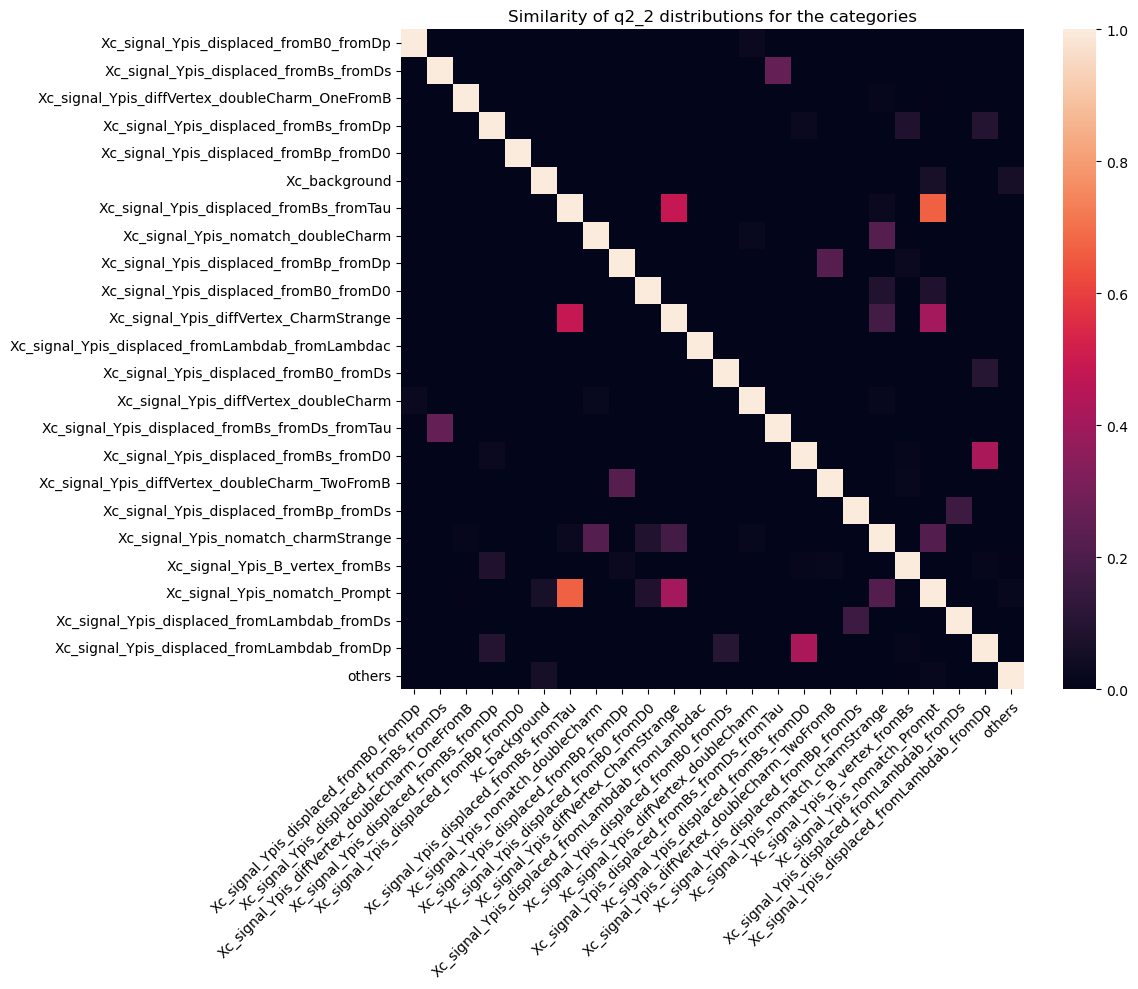

In [13]:
plt.rcParams["figure.figsize"] = (12, 10)
plt.figure()
sn.heatmap(disp_sq2_2)
plt.title("Similarity of q2_2 distributions for the categories");
plt.ylabel("")
plt.xticks(rotation = 45, ha='right', rotation_mode='anchor') 
plt.tight_layout()
plt.savefig("similarity_sq2_2.png",  bbox_inches="tight")

In [35]:
from pprint import pprint
clusters = find_and_merge_clusters(sq2_2, 0.5)
pprint(clusters)
clusters_q2_2 = clusters

[['8'],
 ['others'],
 ['0'],
 ['13'],
 ['2'],
 ['30'],
 ['7'],
 ['21'],
 ['14'],
 ['19'],
 ['20'],
 ['26'],
 ['6', '24'],
 ['28'],
 ['31'],
 ['27'],
 ['16'],
 ['15'],
 ['23'],
 ['29'],
 ['25'],
 ['22'],
 ['18']]


In [36]:
from itertools import zip_longest
pages =  list(zip_longest(*(iter(clusters),) * 6))
pages

[(['8'], ['others'], ['0'], ['13'], ['2'], ['30']),
 (['7'], ['21'], ['14'], ['19'], ['20'], ['26']),
 (['6', '24'], ['28'], ['31'], ['27'], ['16'], ['15']),
 (['23'], ['29'], ['25'], ['22'], ['18'], None)]

In [37]:
def plot_page(var, page, pages):
    plt.rcParams["figure.figsize"] = (20, 30)
    mypage = pages[page]#[ p for p in pages[page] if p is not None ]
    nbcols = 2
    nbrows = 3
    fig, axs = plt.subplots(3, 2)
    print(mypage)
    print(axs.shape)
    for row in range(nbrows):
        c0 = mypage[2 *row]
        c1 = mypage[2 * row + 1]
        if c0:
            plot_templates_categs_in_ax(c0, var, axs[row][0])
        else:
              axs[row][0].axis('off')
        if c1:
            plot_templates_categs_in_ax(c1, var, axs[row][1])
        else:
              axs[row][1].axis('off')
        plt.tight_layout()
        plt.savefig(f"templates_hist_{var}_{page}.png")

(['8'], ['others'], ['0'], ['13'], ['2'], ['30'])
(3, 2)


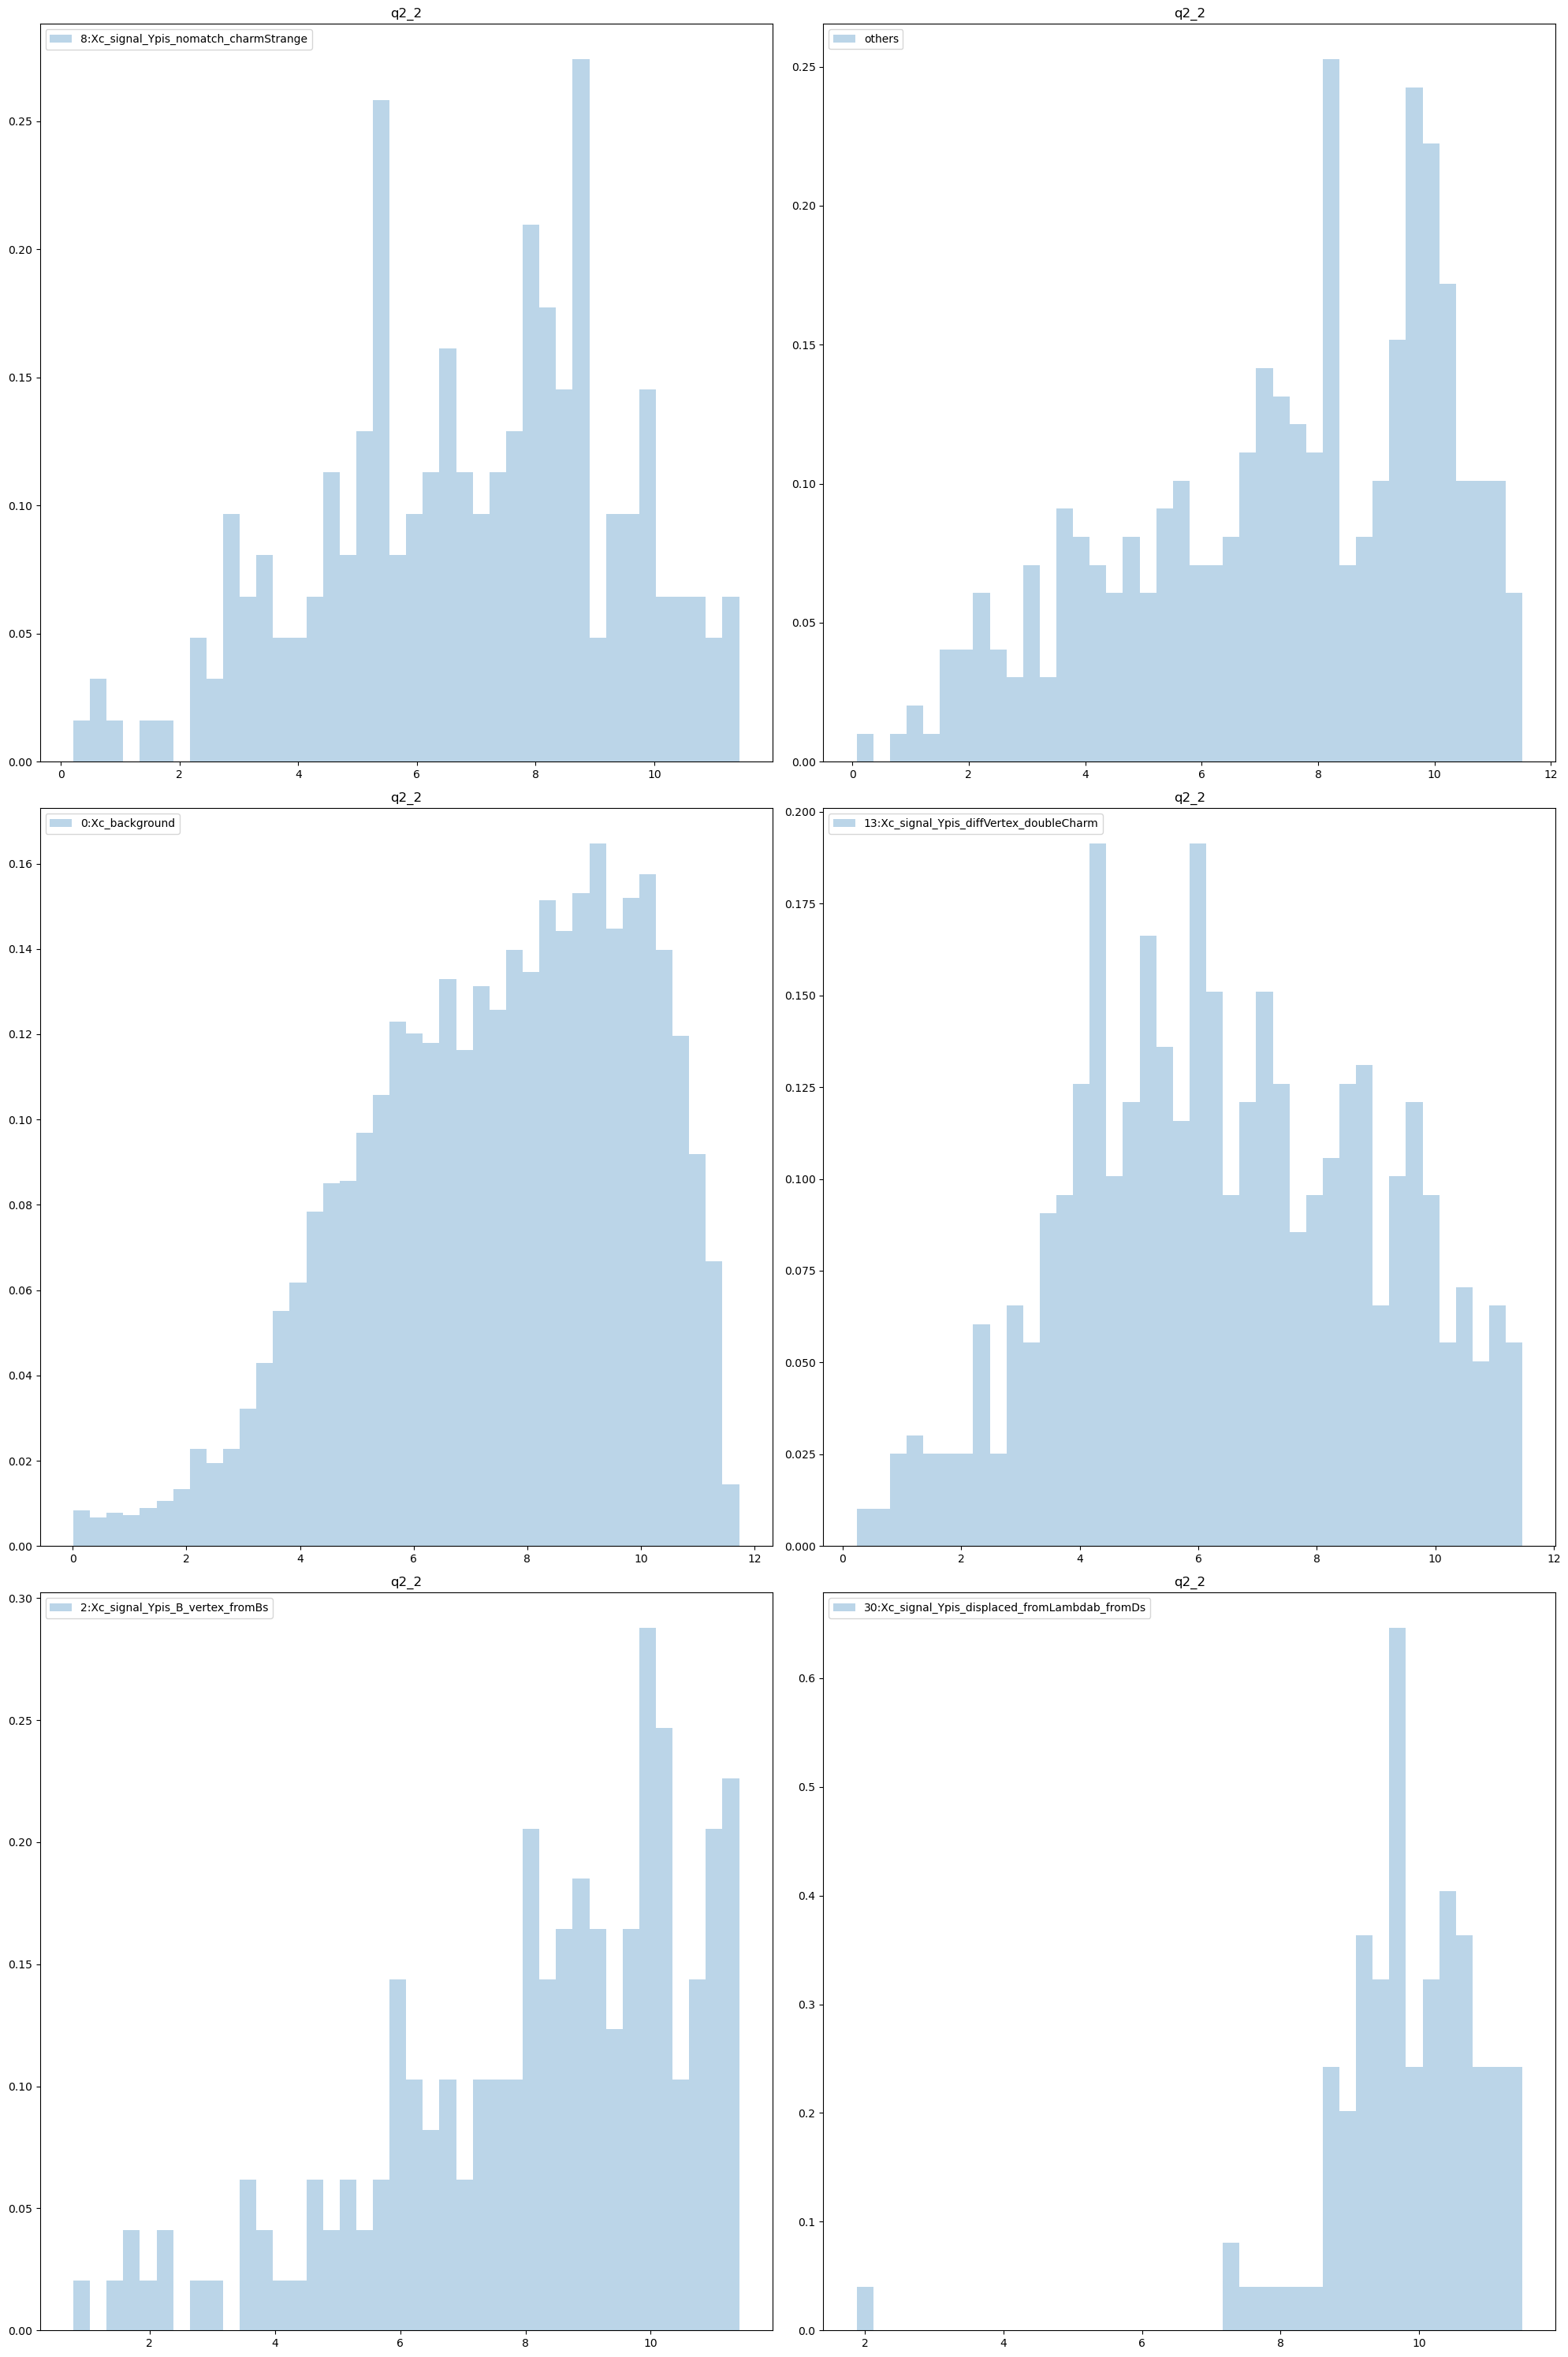

In [38]:
plot_page("q2_2", 0, pages)

(['7'], ['21'], ['14'], ['19'], ['20'], ['26'])
(3, 2)


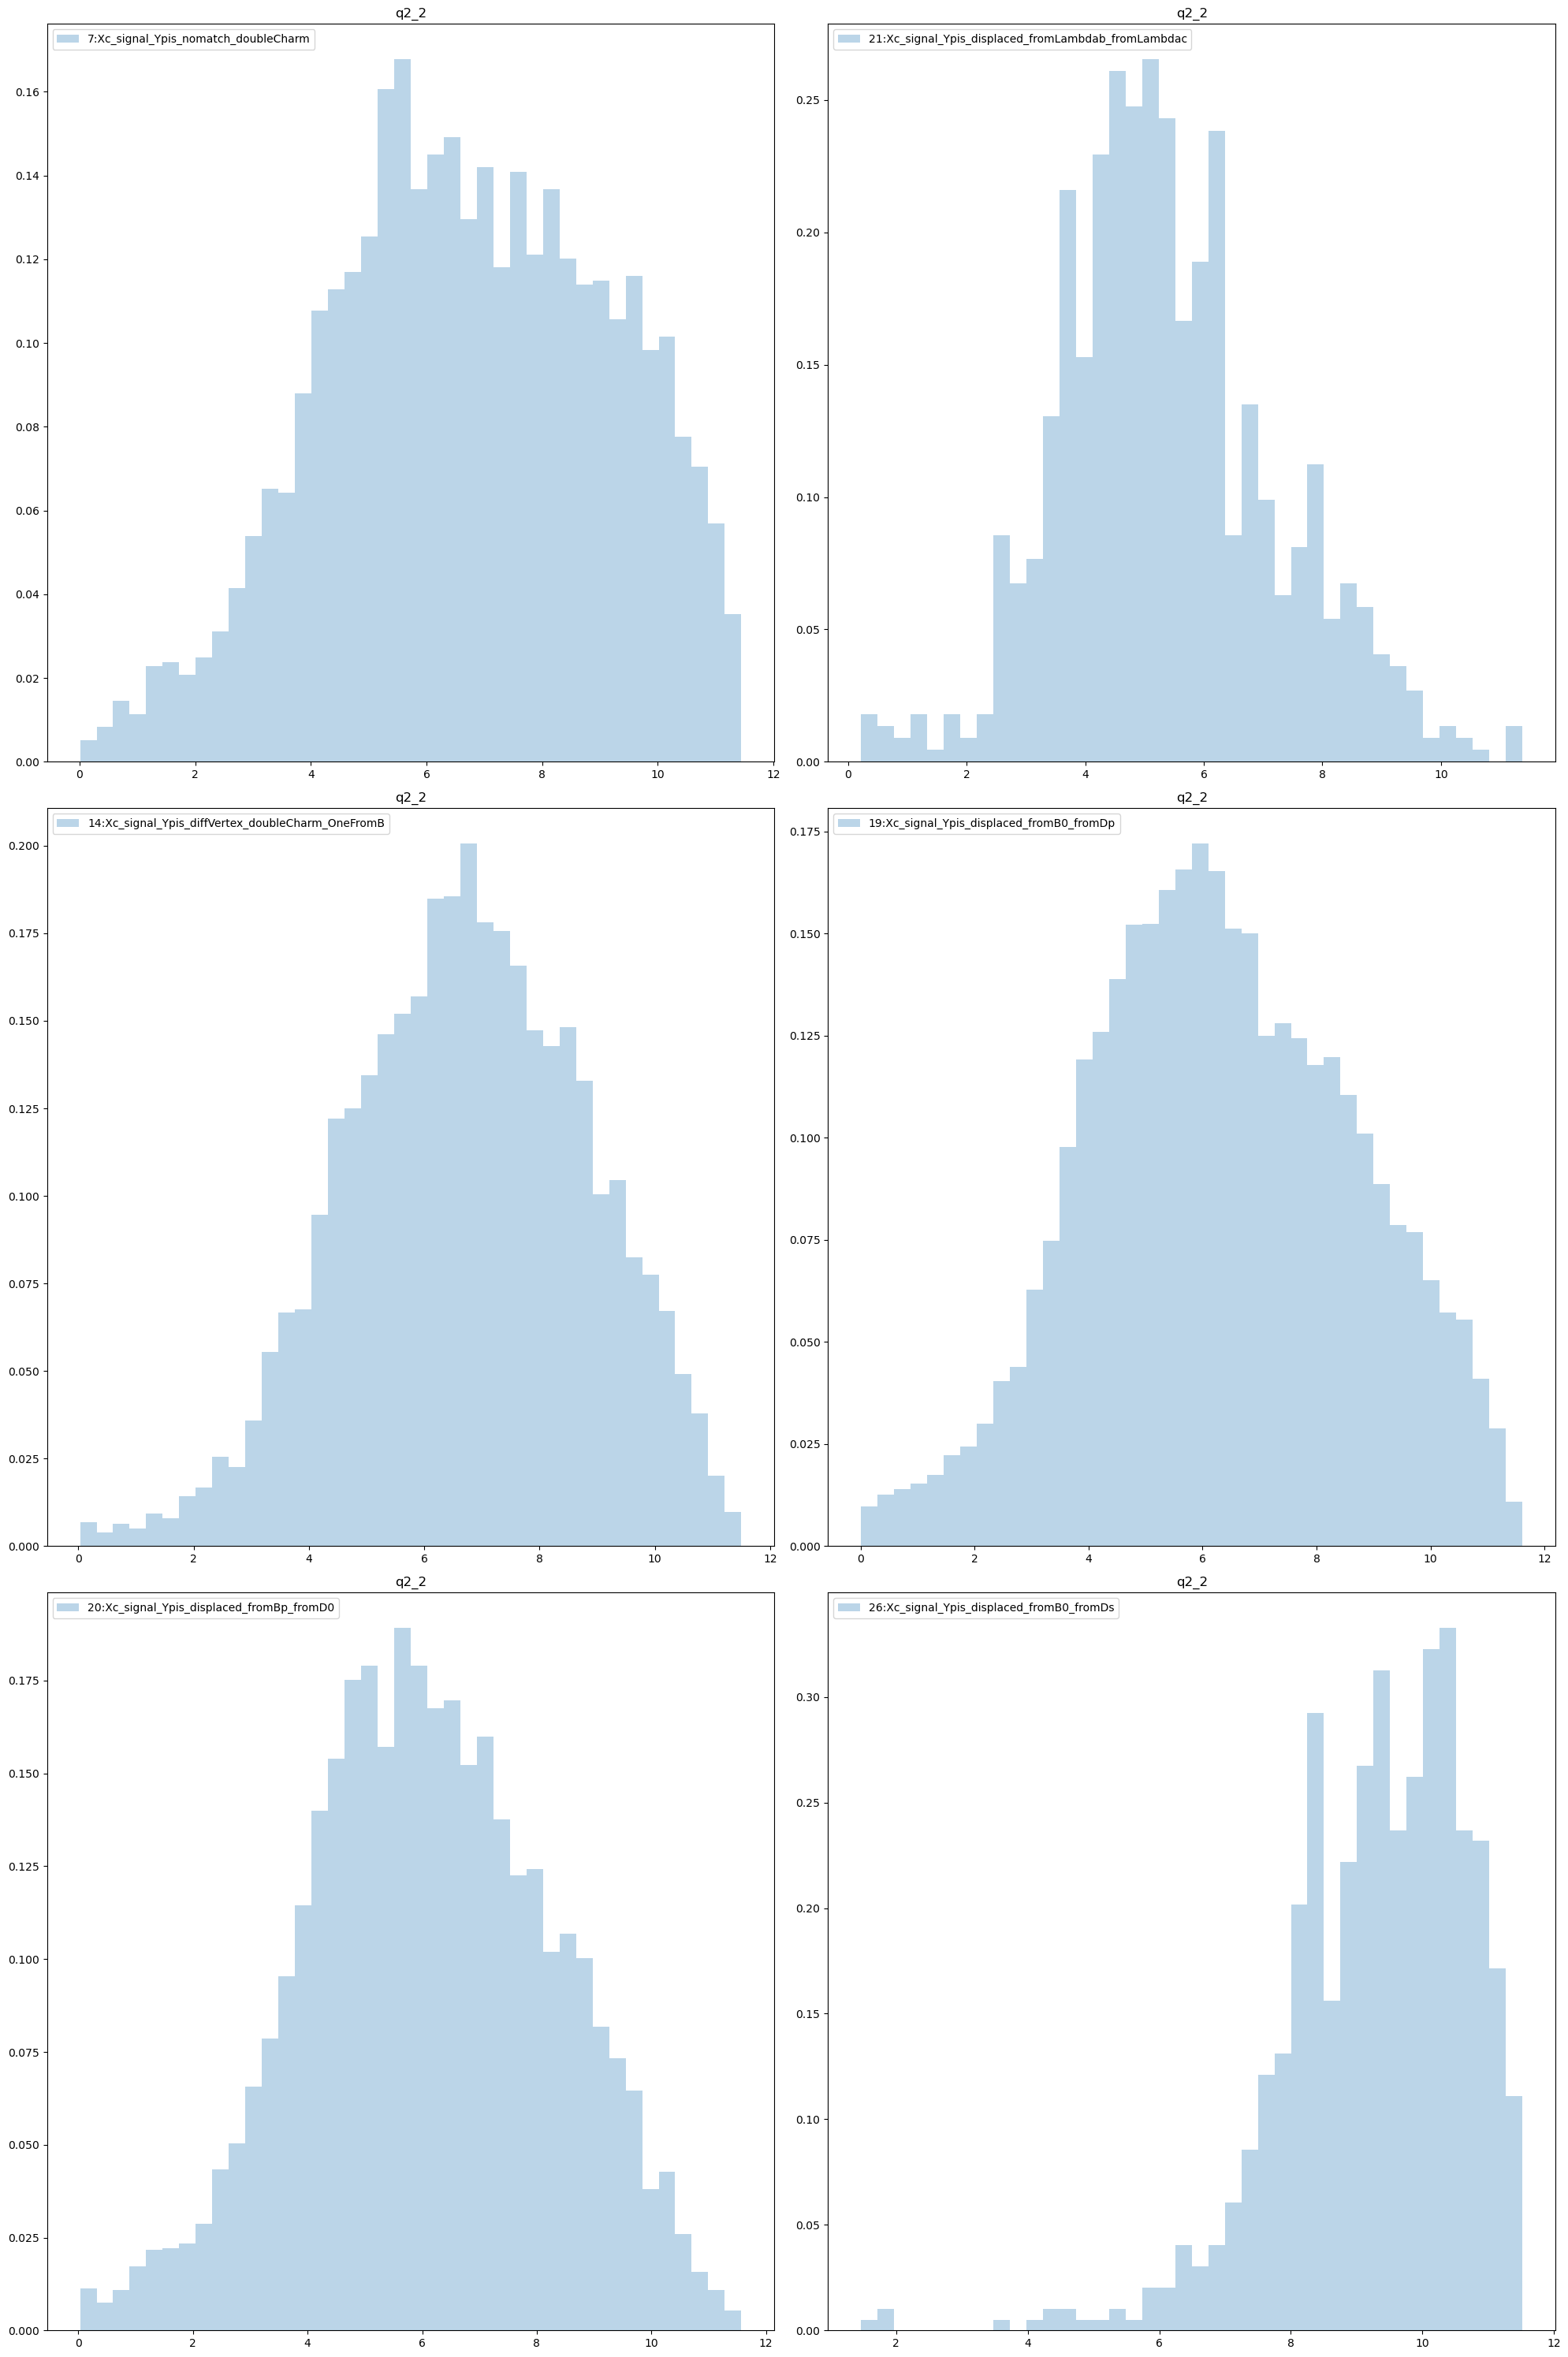

In [39]:
plot_page("q2_2", 1, pages)

(['6', '24'], ['28'], ['31'], ['27'], ['16'], ['15'])
(3, 2)


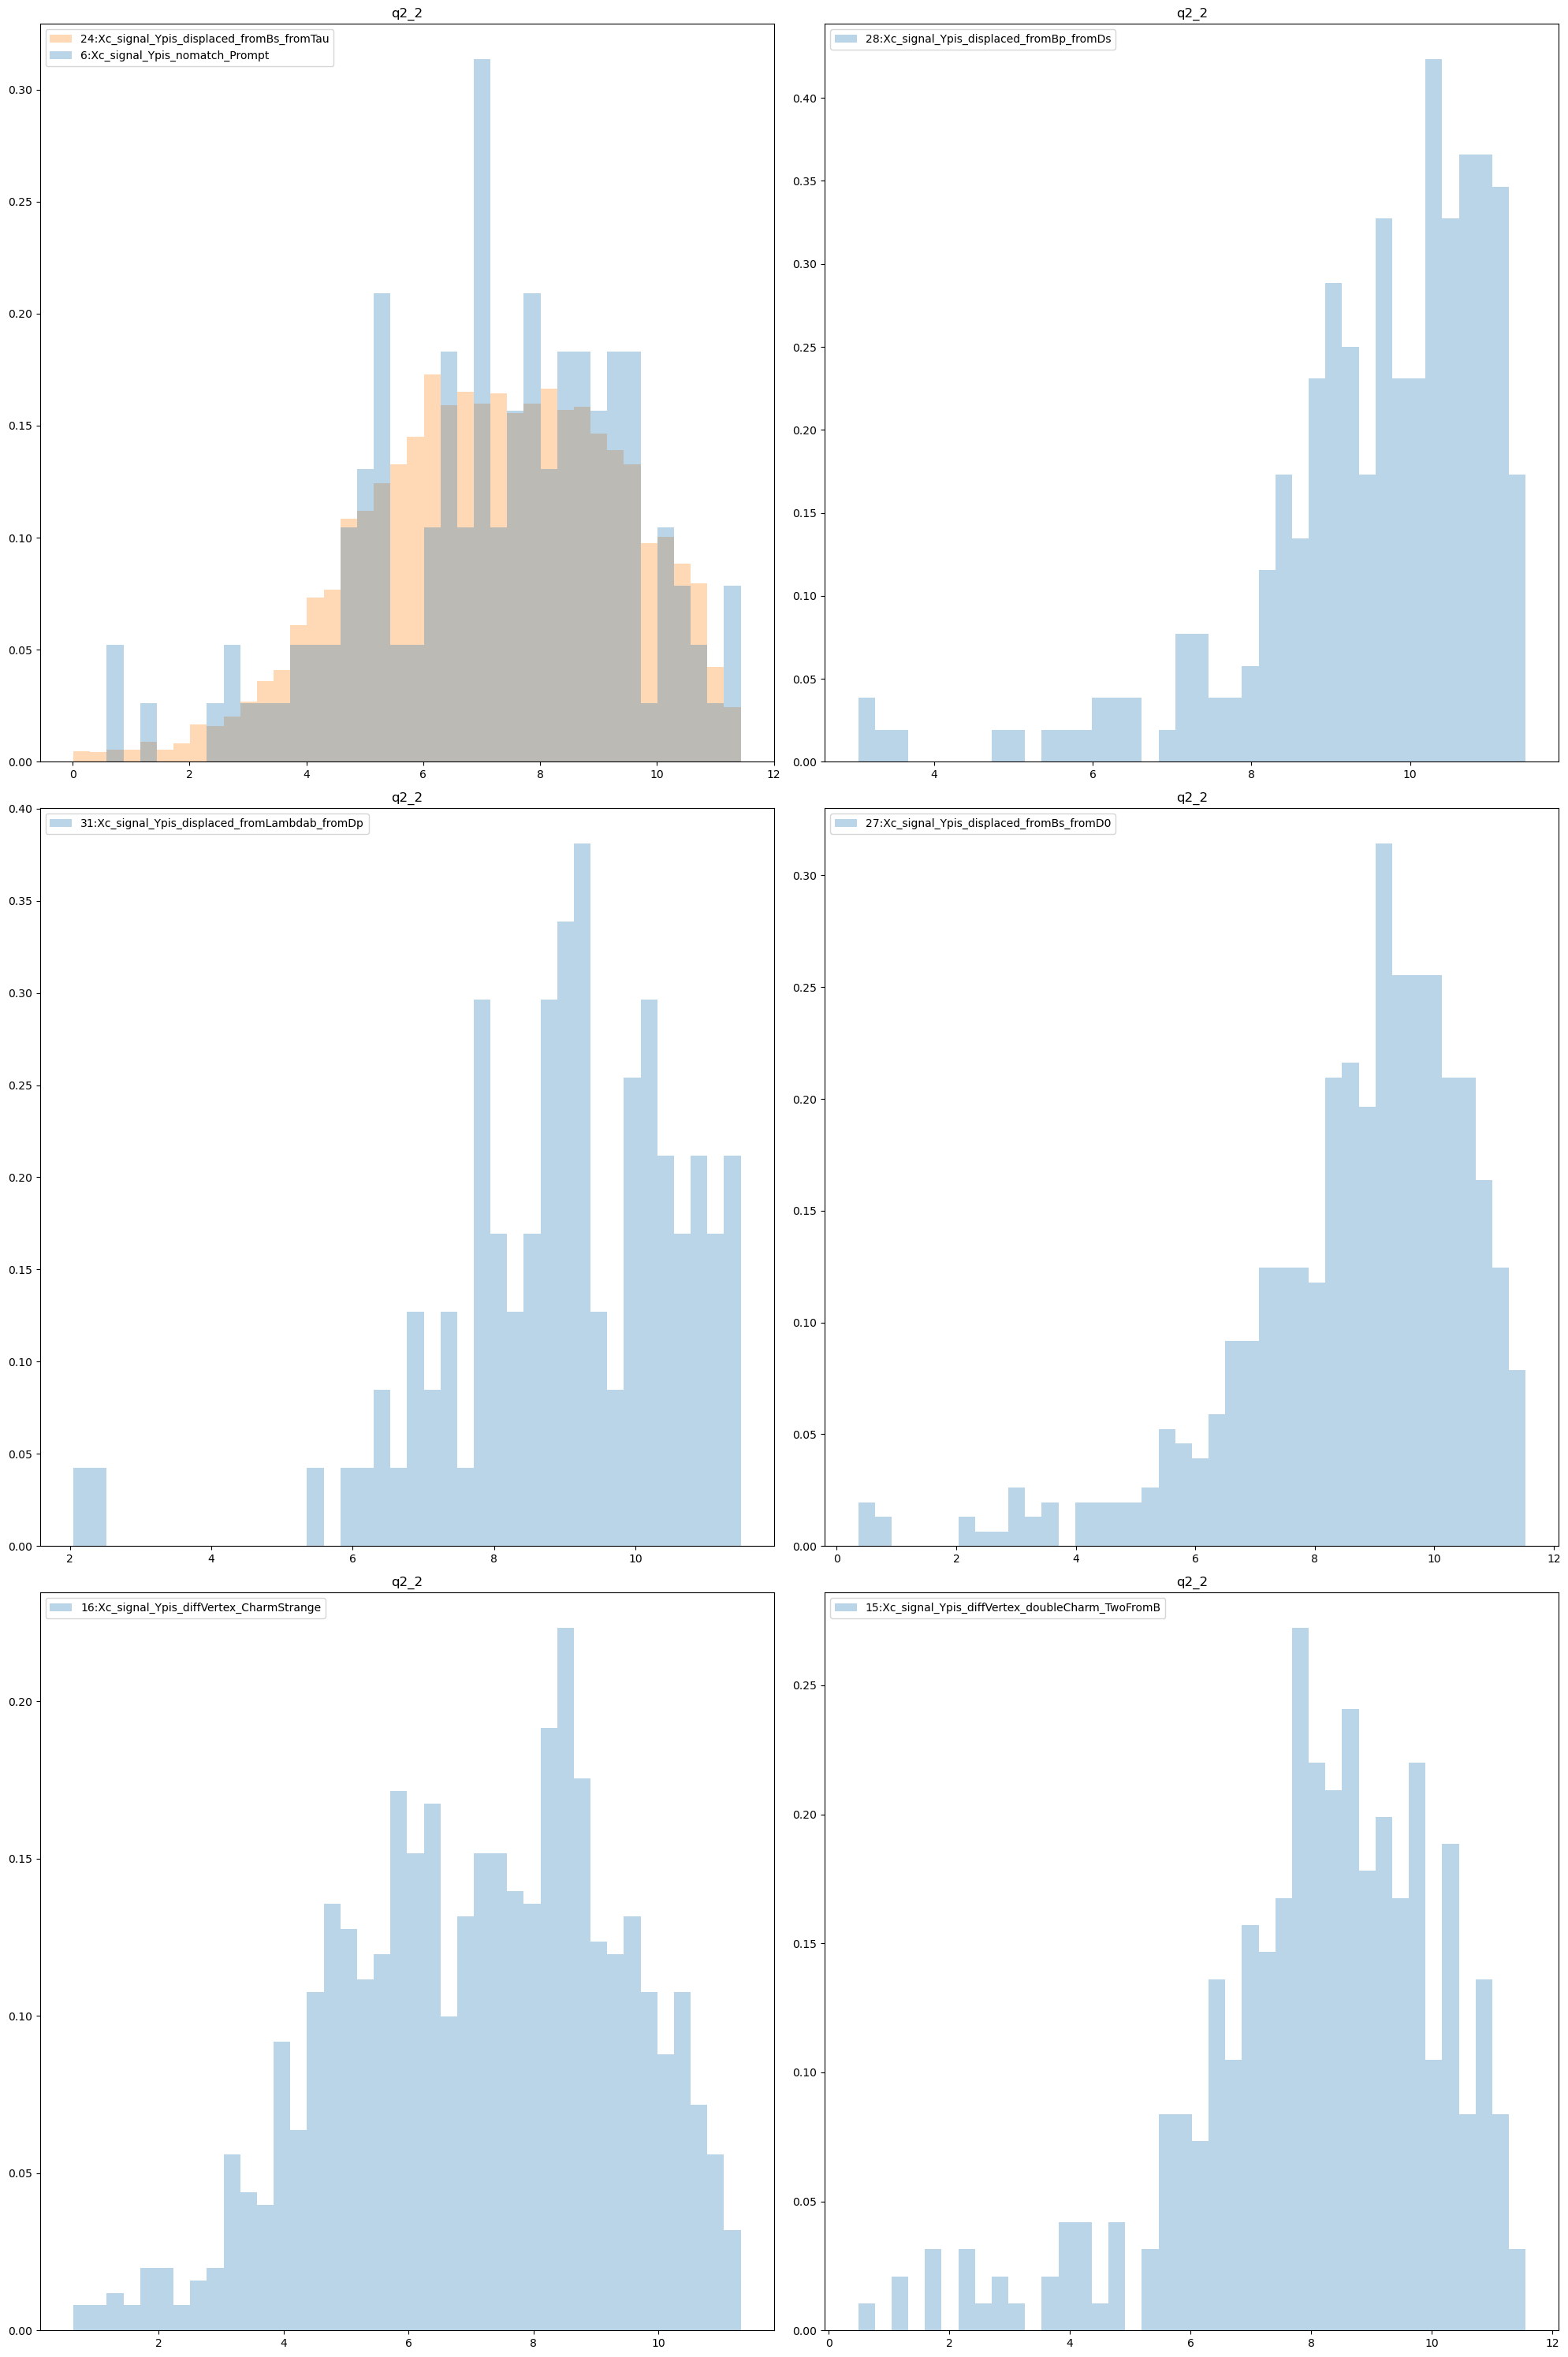

In [40]:
plot_page("q2_2", 2, pages)

## Checking tauY_2 distributions

In [ ]:
plt.rcParams["figure.figsize"] = (12, 10)
plt.figure()
disp_stauY_2 = stauY_2.copy()
disp_stauY_2.rename(categories, axis=1, inplace=True)
disp_stauY_2.rename(categories, axis=0, inplace=True)
plt.title("Similarity of tauY_2 distributions for the categories");
sn.heatmap(disp_stauY_2)
plt.ylabel("")
plt.xticks(rotation = 45, ha='right', rotation_mode='anchor') 
plt.tight_layout()
plt.savefig("similarity_stauY_2.png",  bbox_inches="tight")



In [ ]:
from pprint import pprint
clusters = find_and_merge_clusters(stauY_2, 0.5)
pprint(clusters)

clusters_tauY_2 = clusters

In [ ]:
from itertools import zip_longest
pages =  list(zip_longest(*(iter(clusters_tauY_2),) * 6))
pages

(['13'], ['21'], ['28', '30'], ['18', '29'], ['14'], ['19'])
(3, 2)


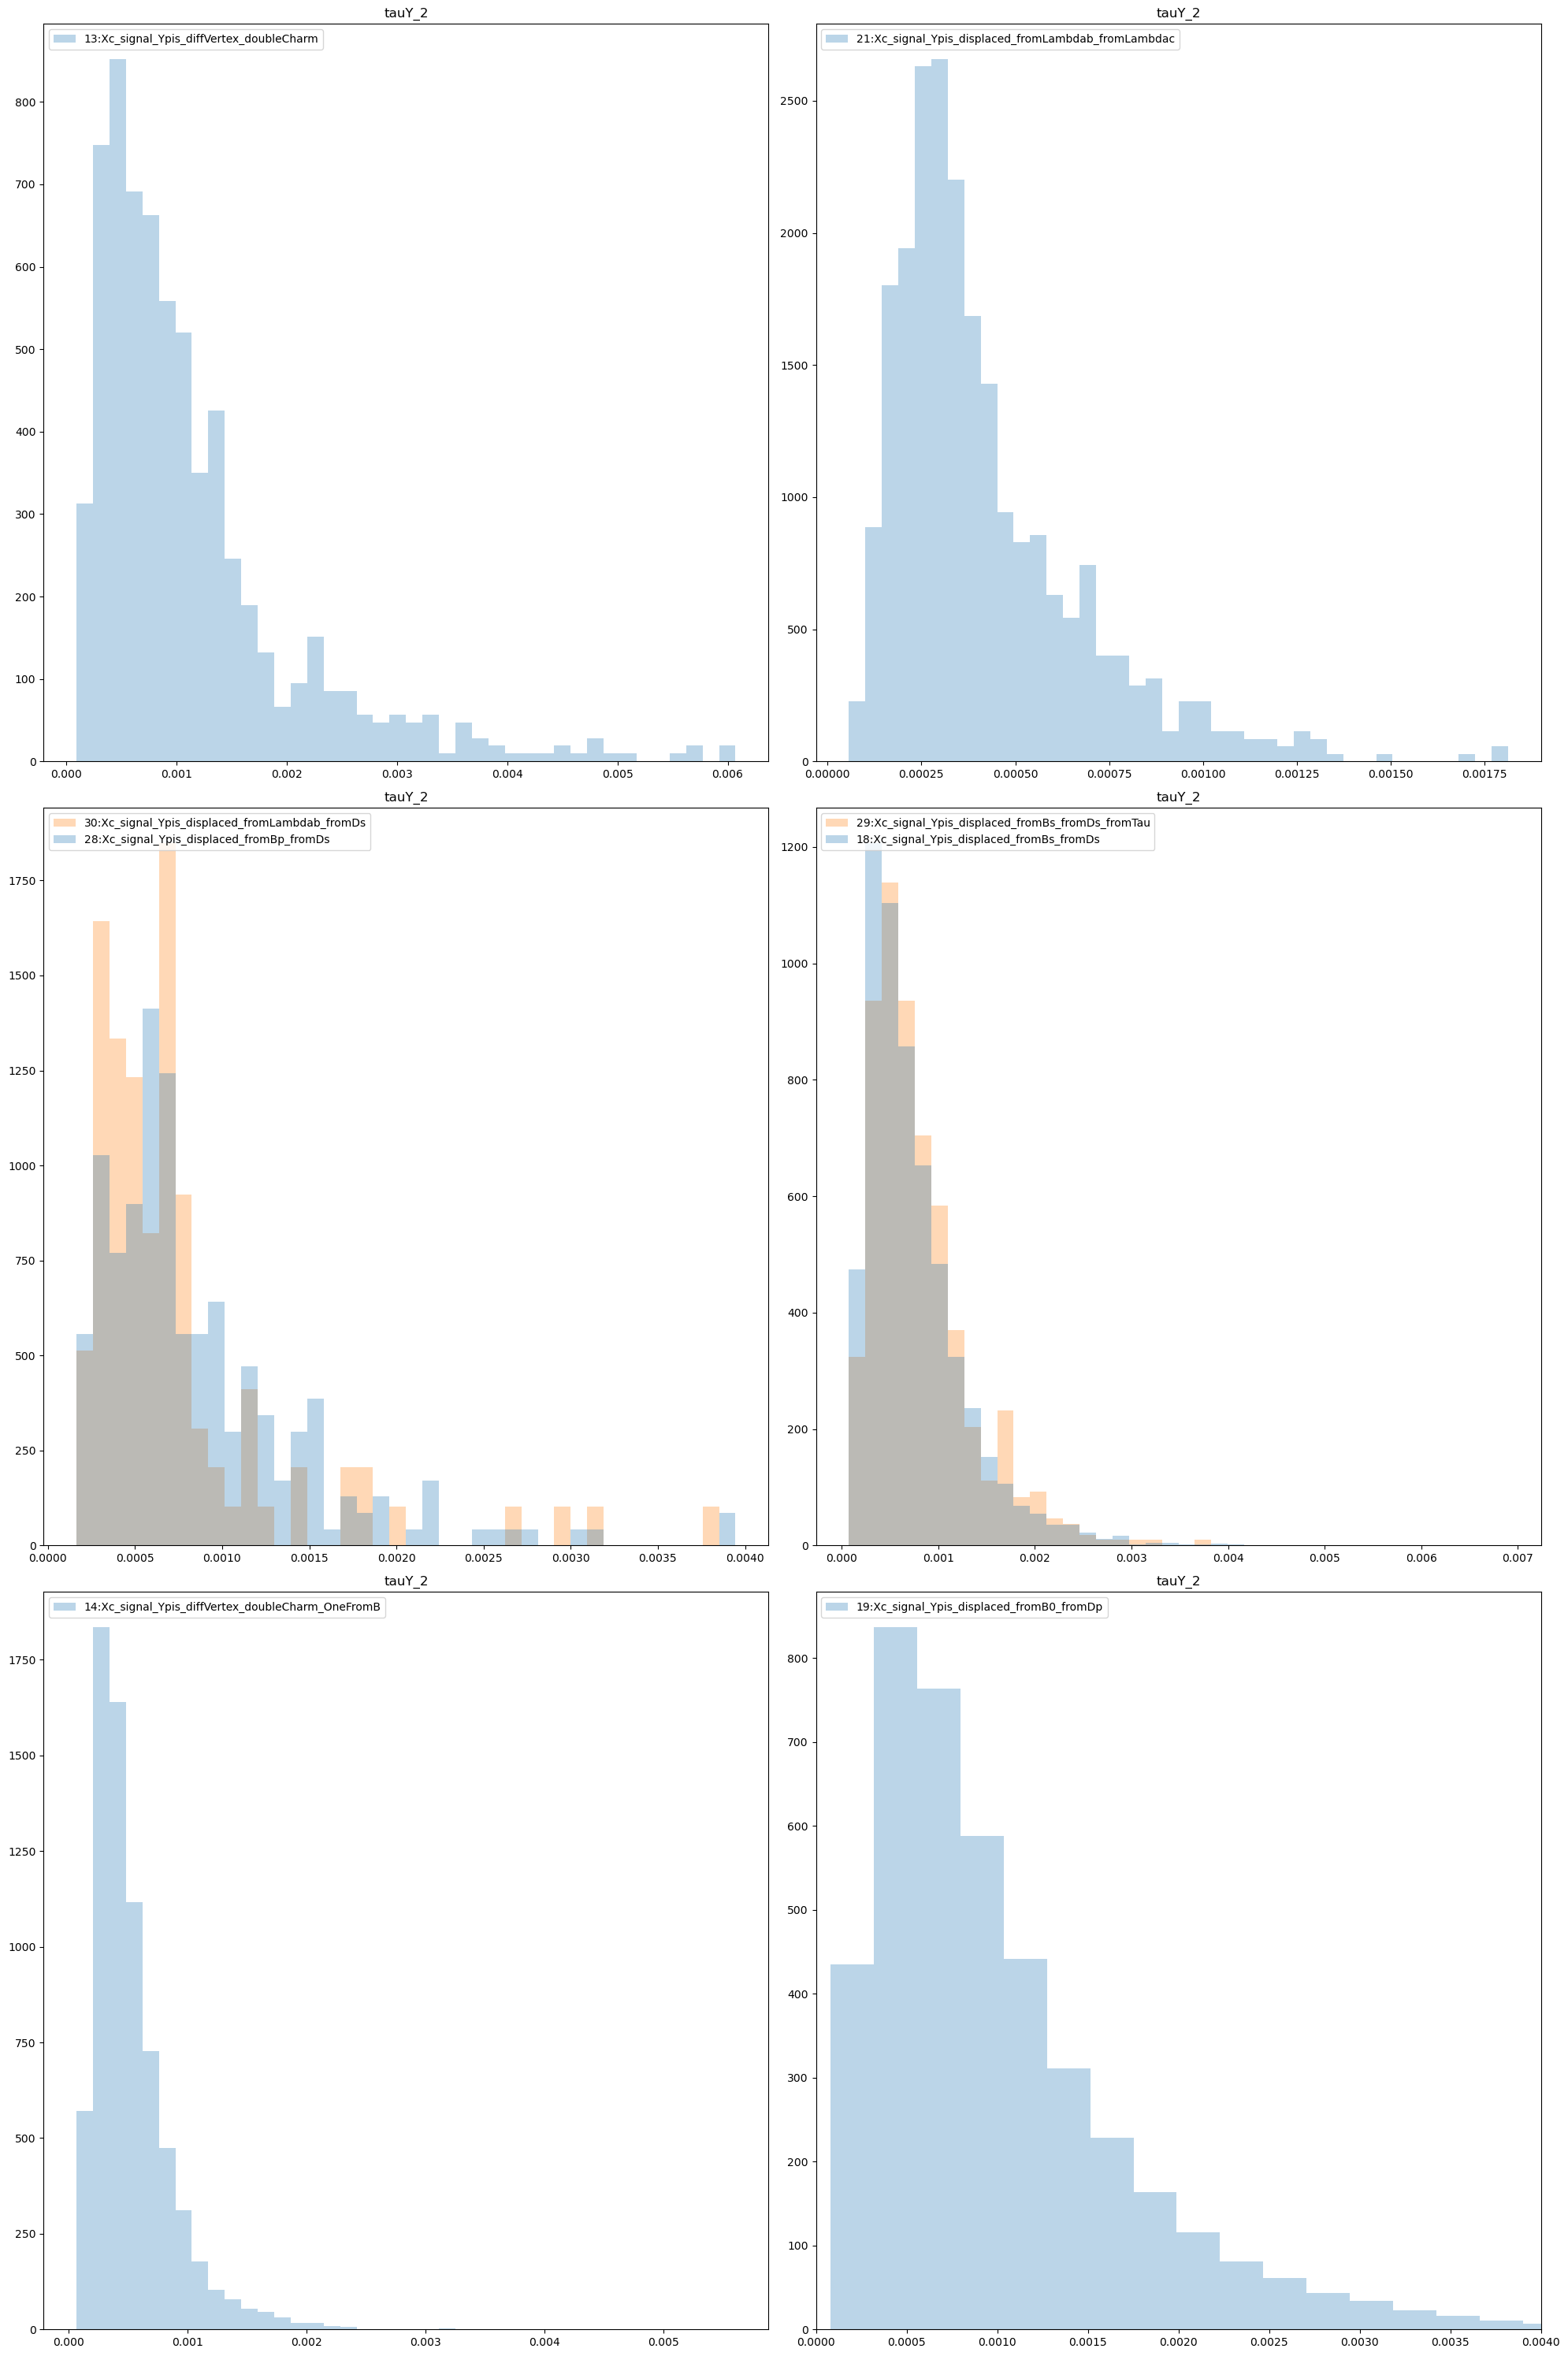

In [27]:
plot_page("tauY_2", 0, pages)
# plt.rcParams["figure.figsize"] = (15,4)
# for c in clusters:
#     plt.figure()
#     plot_templates_categs(c, 'tauY_2')

(['20'], ['8', '25', '0', '24', 'others', '16', '6', '7'], ['27', '2', '22', '26', '31'], ['15', '23'], None, None)
(3, 2)


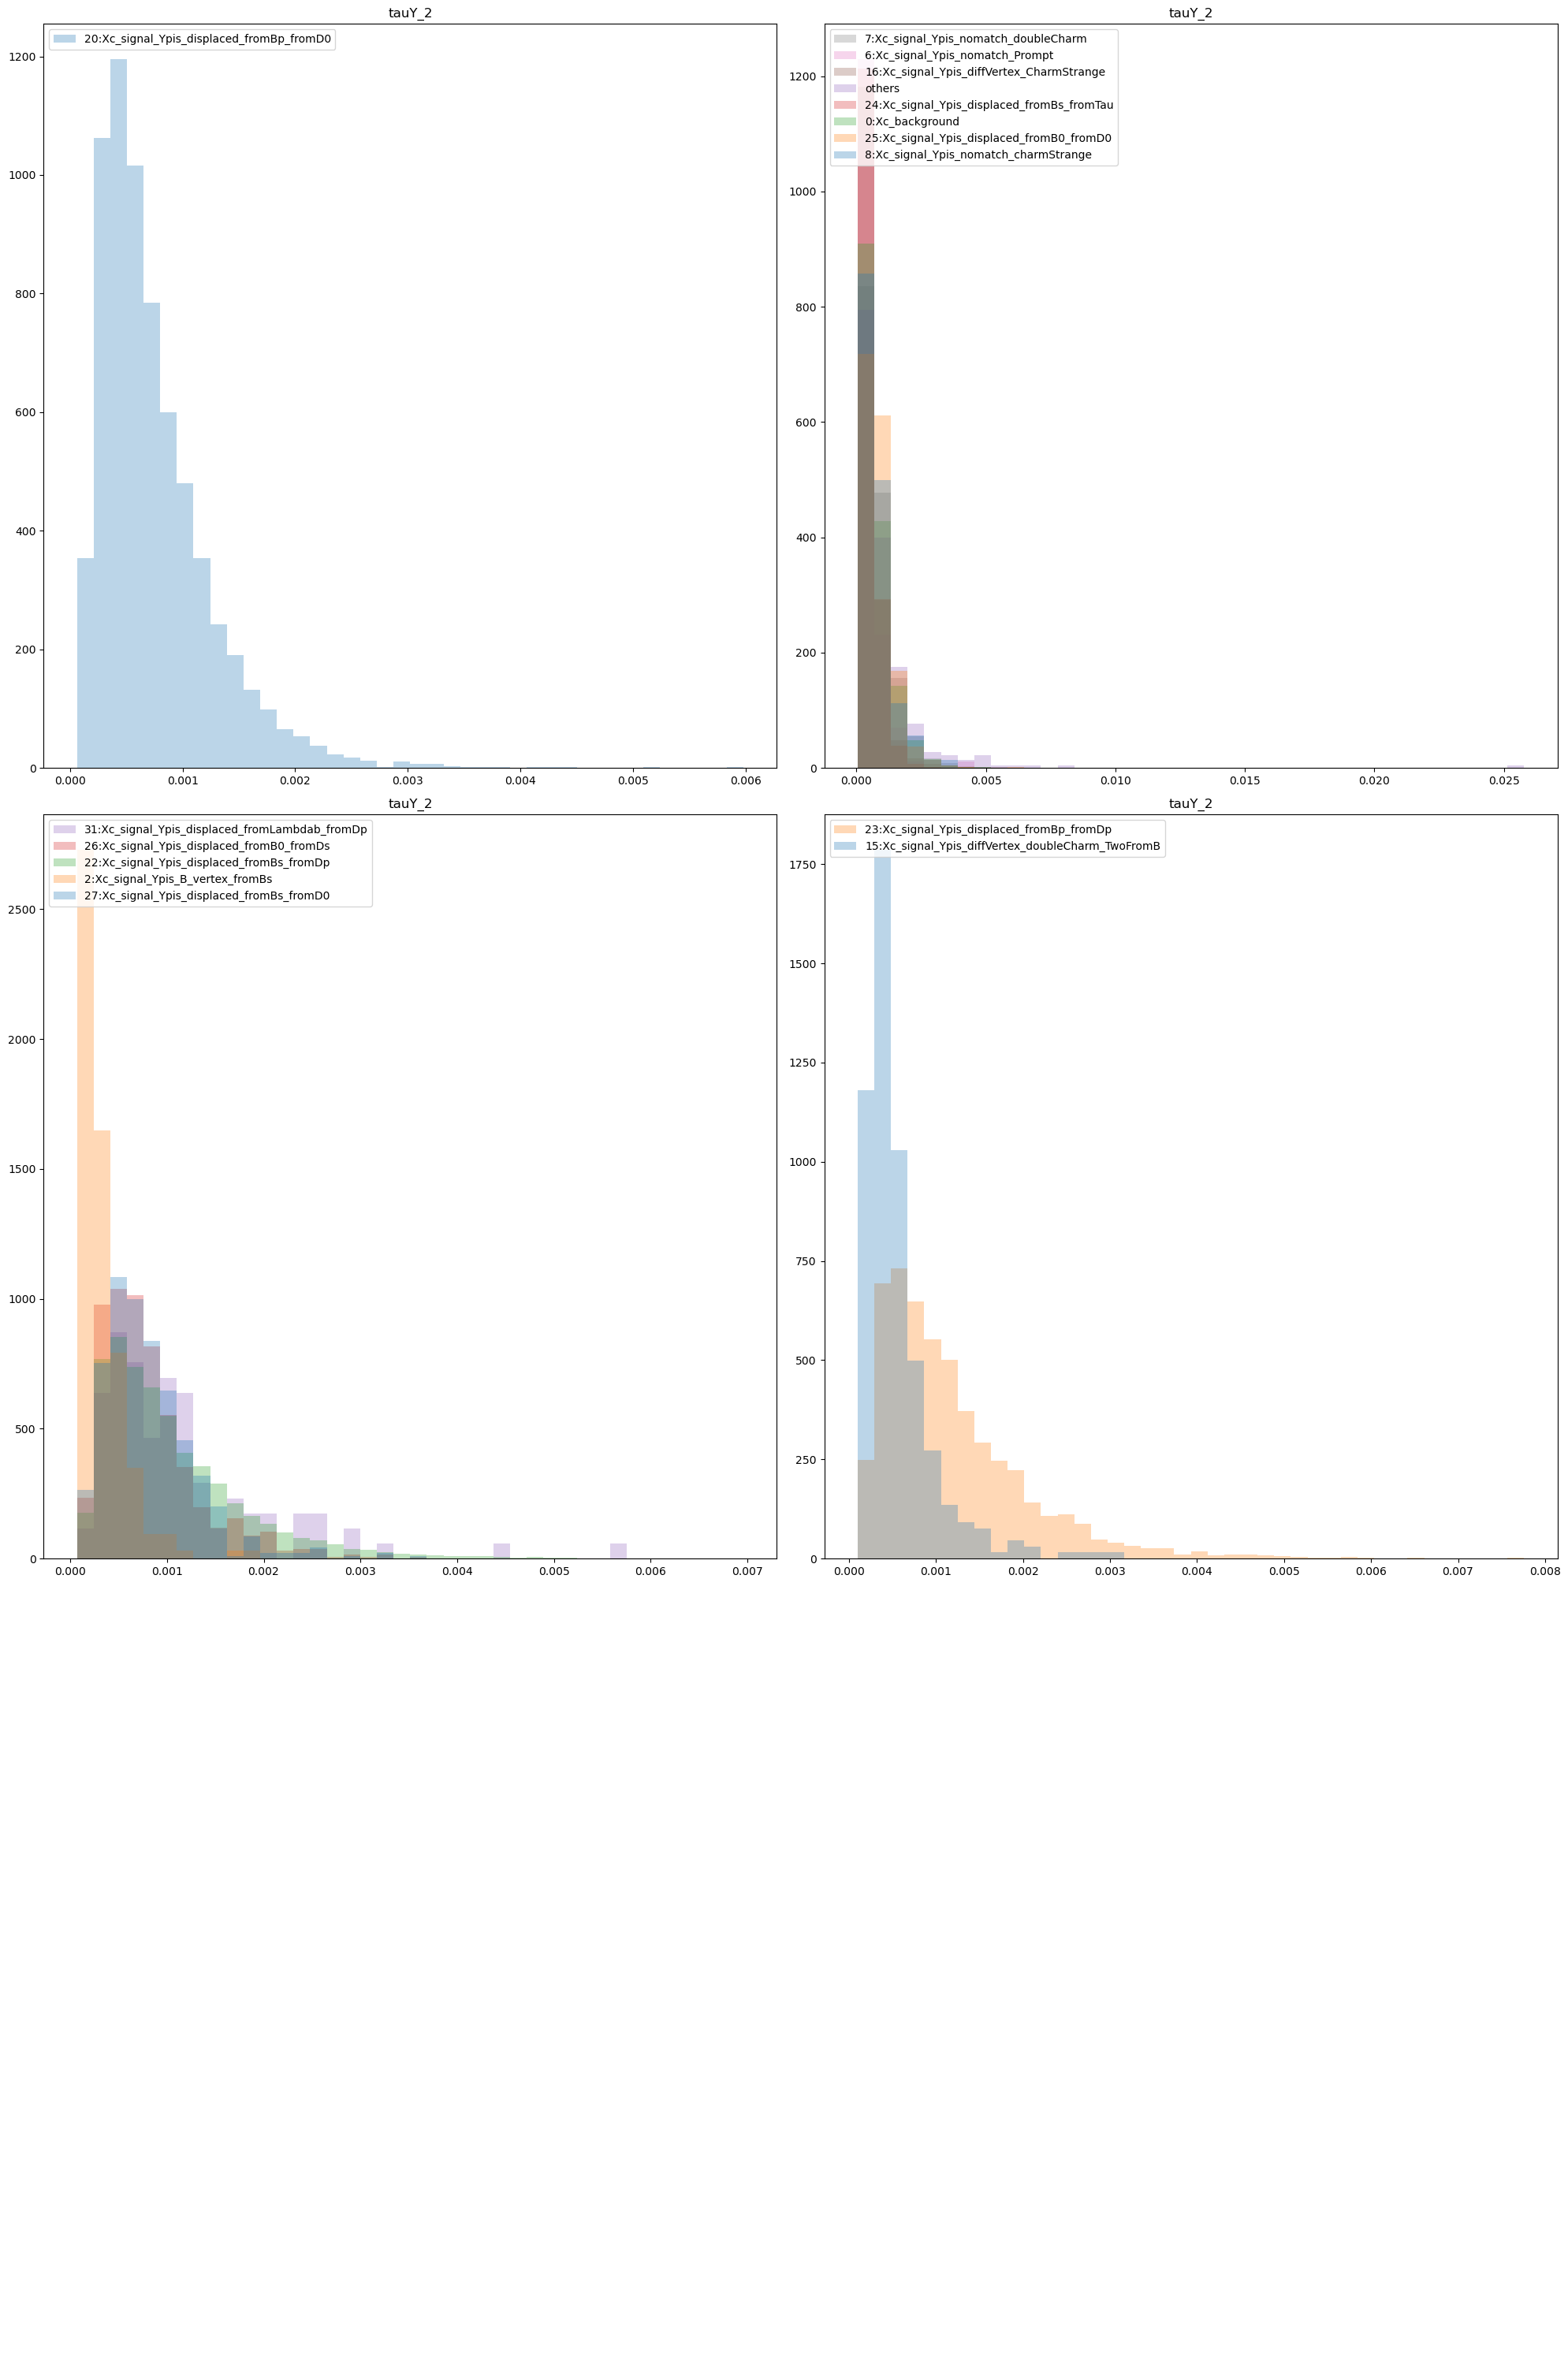

In [28]:
plot_page("tauY_2", 1, pages)

## Checking bdt_all distributions

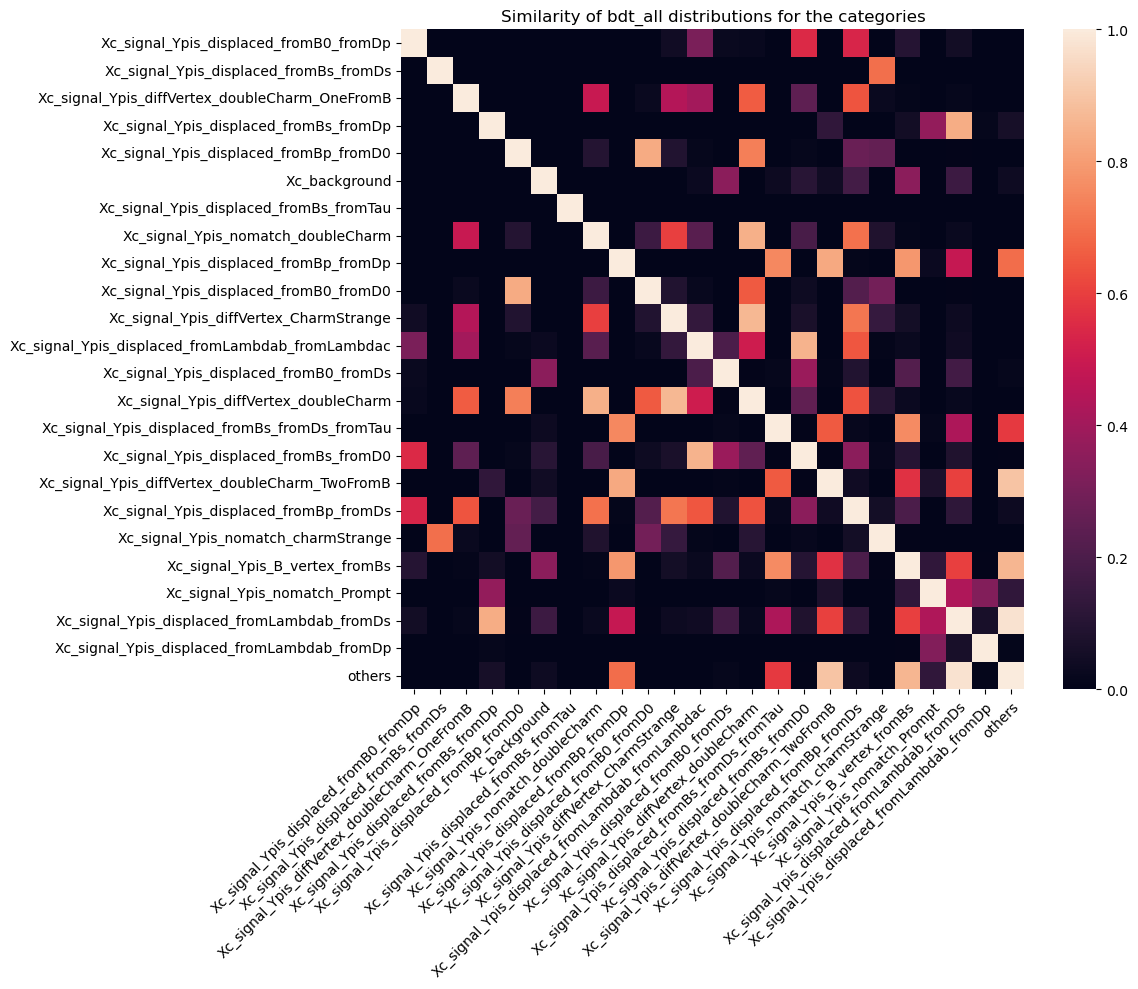

In [29]:
plt.rcParams["figure.figsize"] = (12, 10)
plt.figure()
disp_sbdt_all = sbdt_all.copy()
disp_sbdt_all.rename(categories, axis=1, inplace=True)
disp_sbdt_all.rename(categories, axis=0, inplace=True)
sn.heatmap(disp_sbdt_all)
plt.title("Similarity of bdt_all distributions for the categories");
plt.ylabel("")
plt.xticks(rotation = 45, ha='right', rotation_mode='anchor') 
plt.tight_layout()
plt.savefig("similarity_sbdt_all_2.png",  bbox_inches="tight")

In [30]:
from pprint import pprint
clusters = find_and_merge_clusters(sbdt_all, 0.5)
pprint(clusters)

clusters_bdt_dc = clusters

[['24'],
 ['26'],
 ['18', '8'],
 ['0'],
 ['6'],
 ['31'],
 ['20', '25', '13', '19', '28', '7', '27', '14', '16', '21'],
 ['15', '23', '2', 'others', '22', '29', '30']]


In [31]:
from itertools import zip_longest
pages =  list(zip_longest(*(iter(clusters_bdt_dc),) * 6))
pages

[(['24'], ['26'], ['18', '8'], ['0'], ['6'], ['31']),
 (['20', '25', '13', '19', '28', '7', '27', '14', '16', '21'],
  ['15', '23', '2', 'others', '22', '29', '30'],
  None,
  None,
  None,
  None)]

(['24'], ['26'], ['18', '8'], ['0'], ['6'], ['31'])
(3, 2)


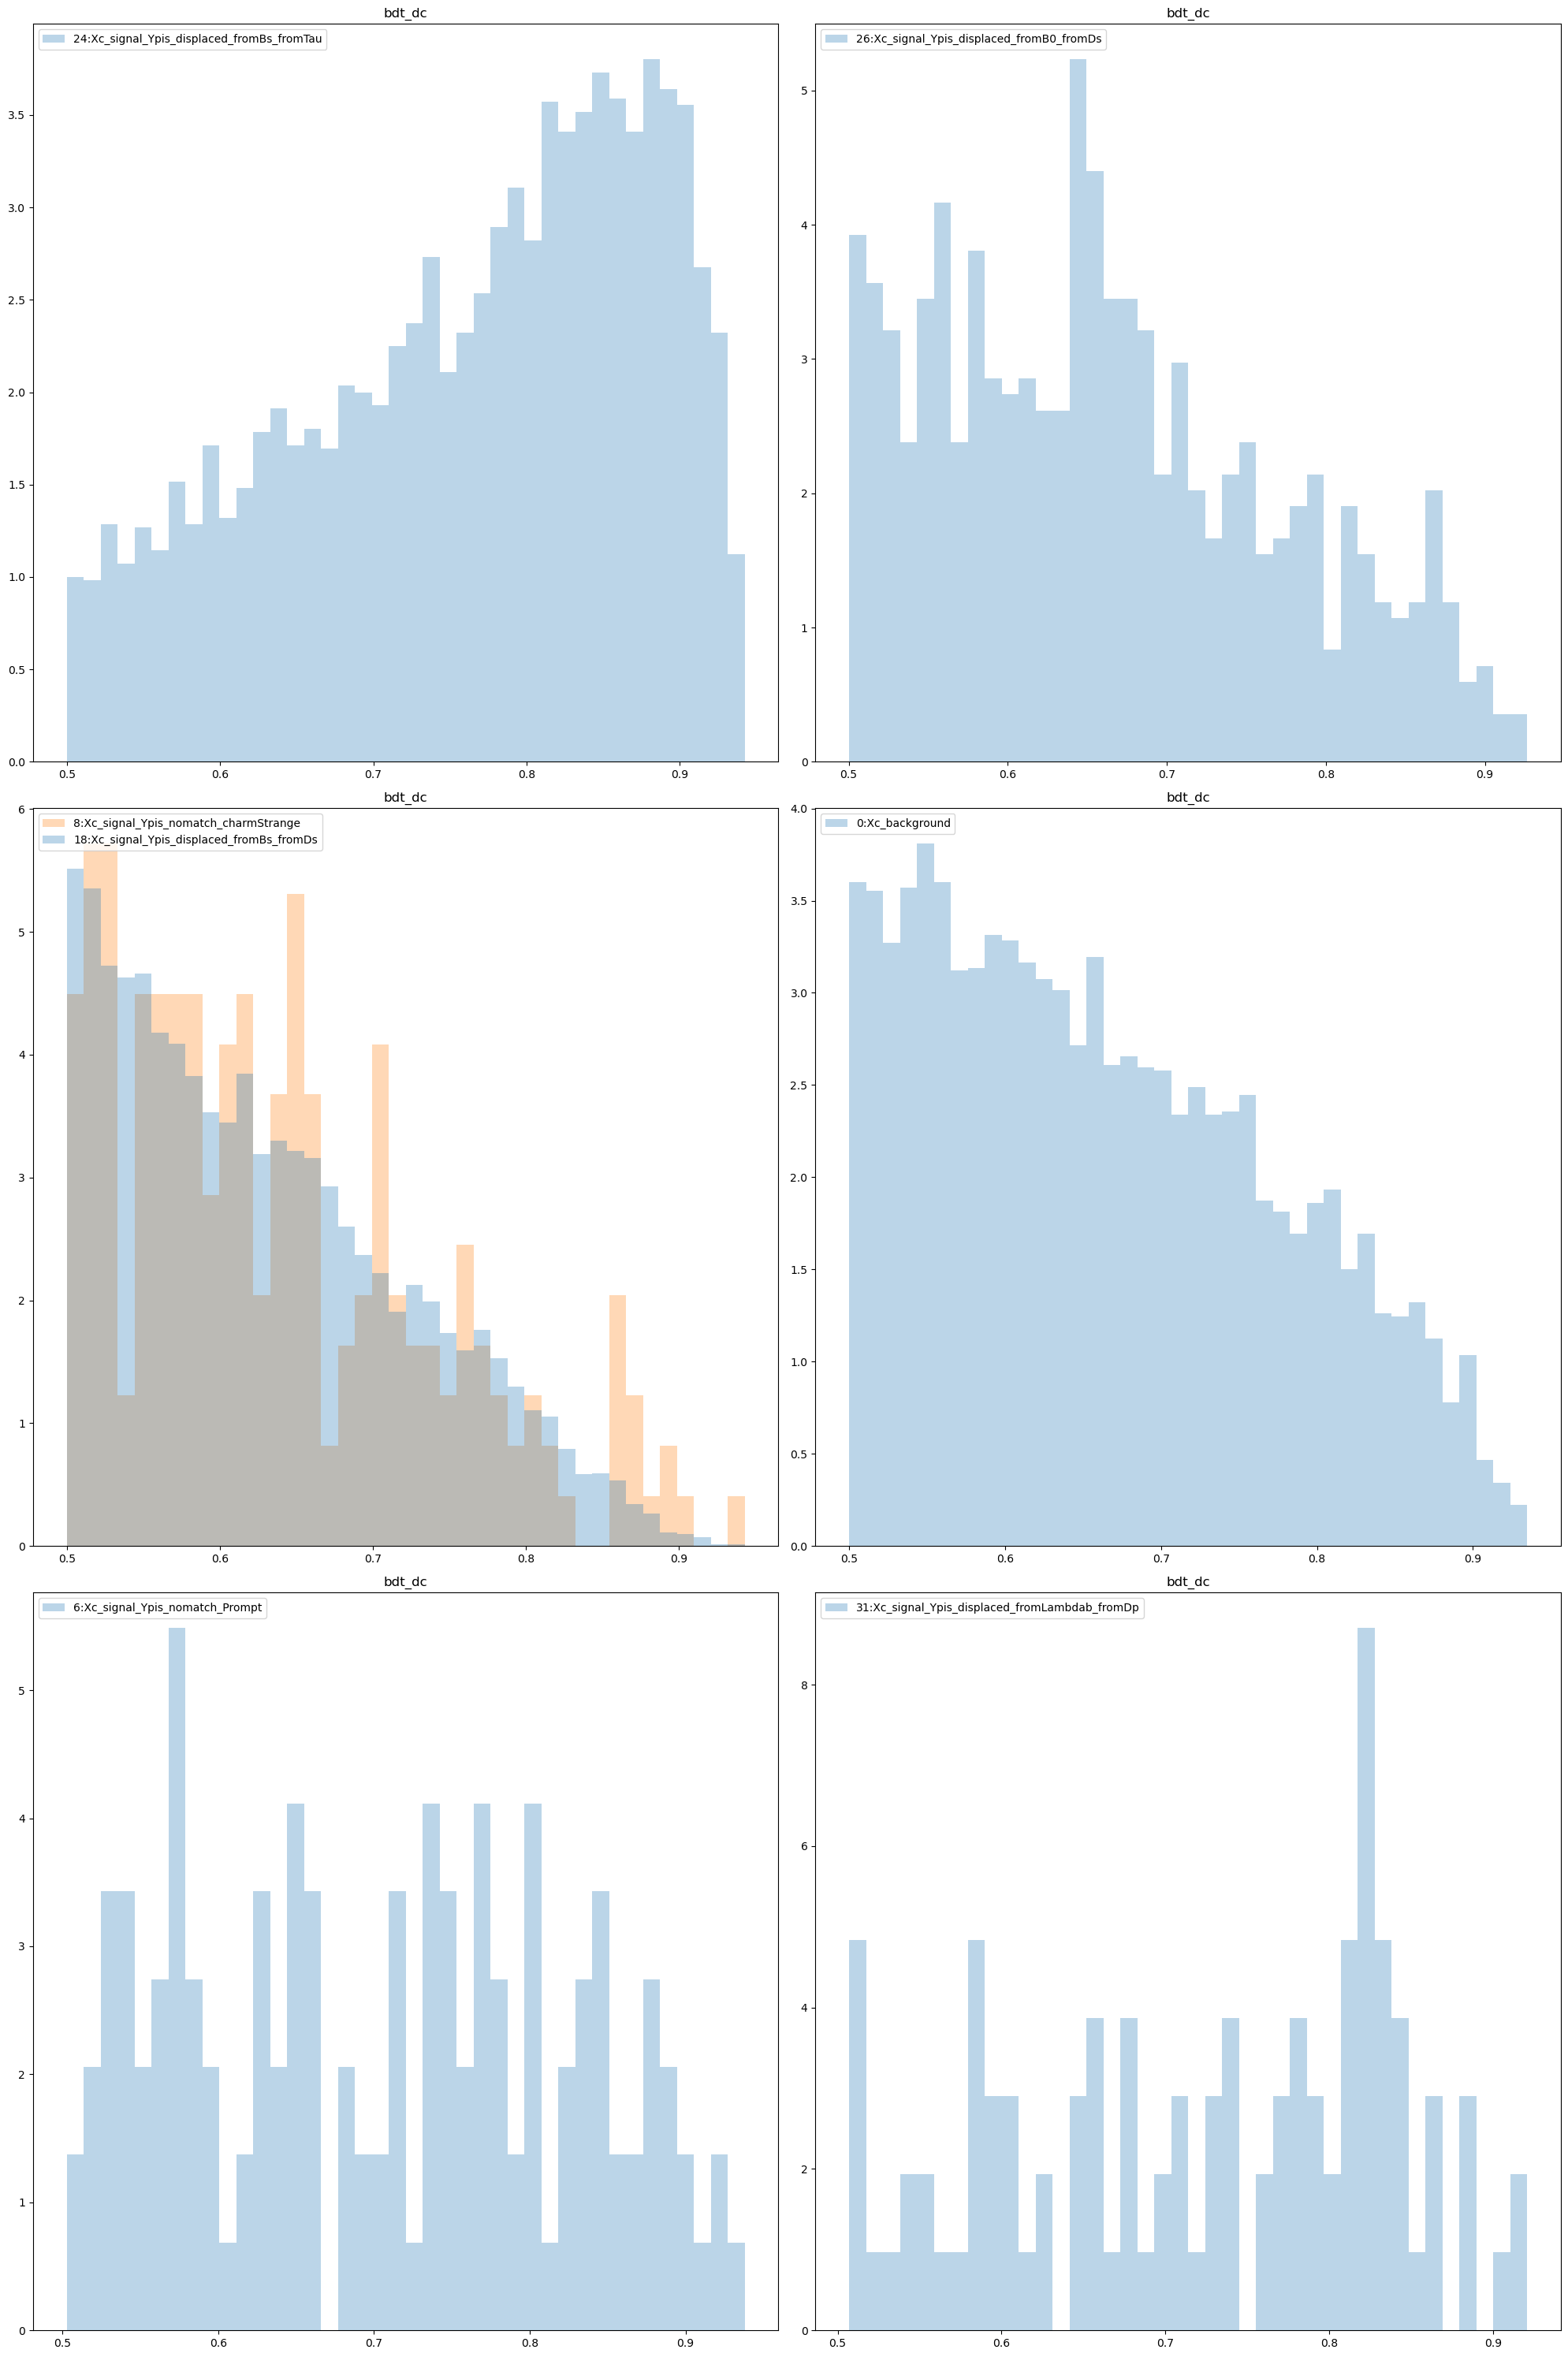

In [32]:
plot_page("bdt_dc", 0, pages)

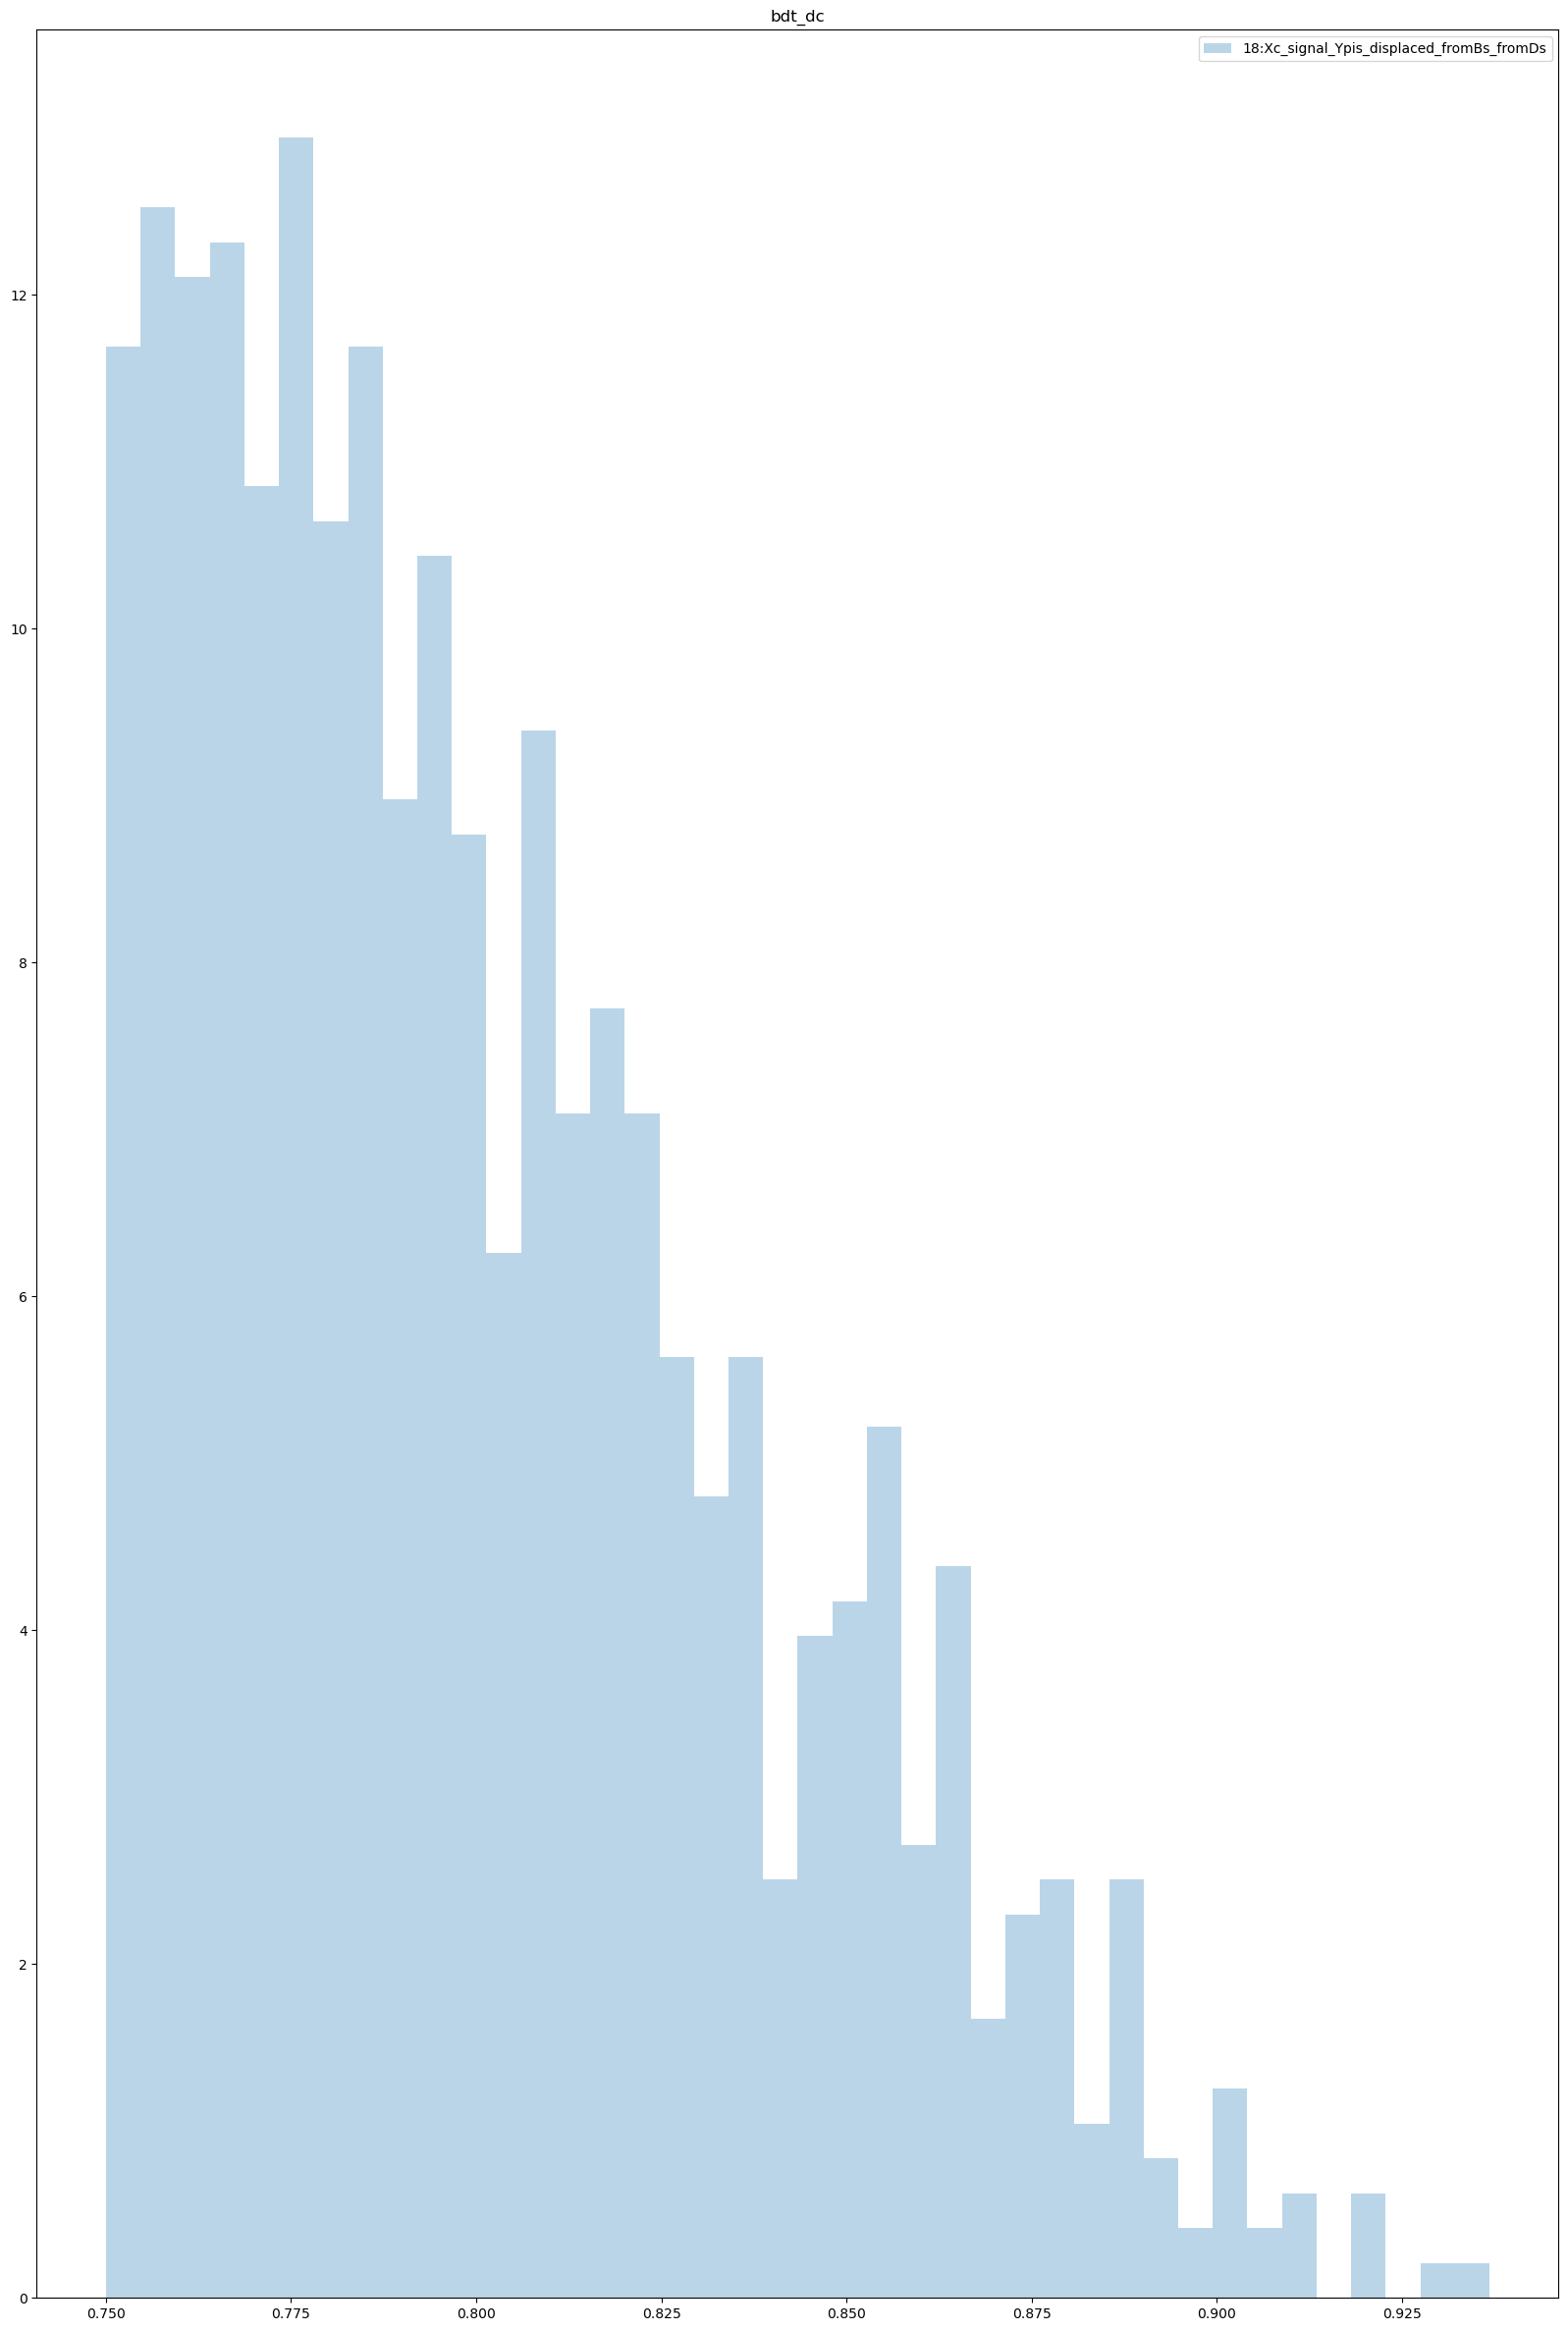

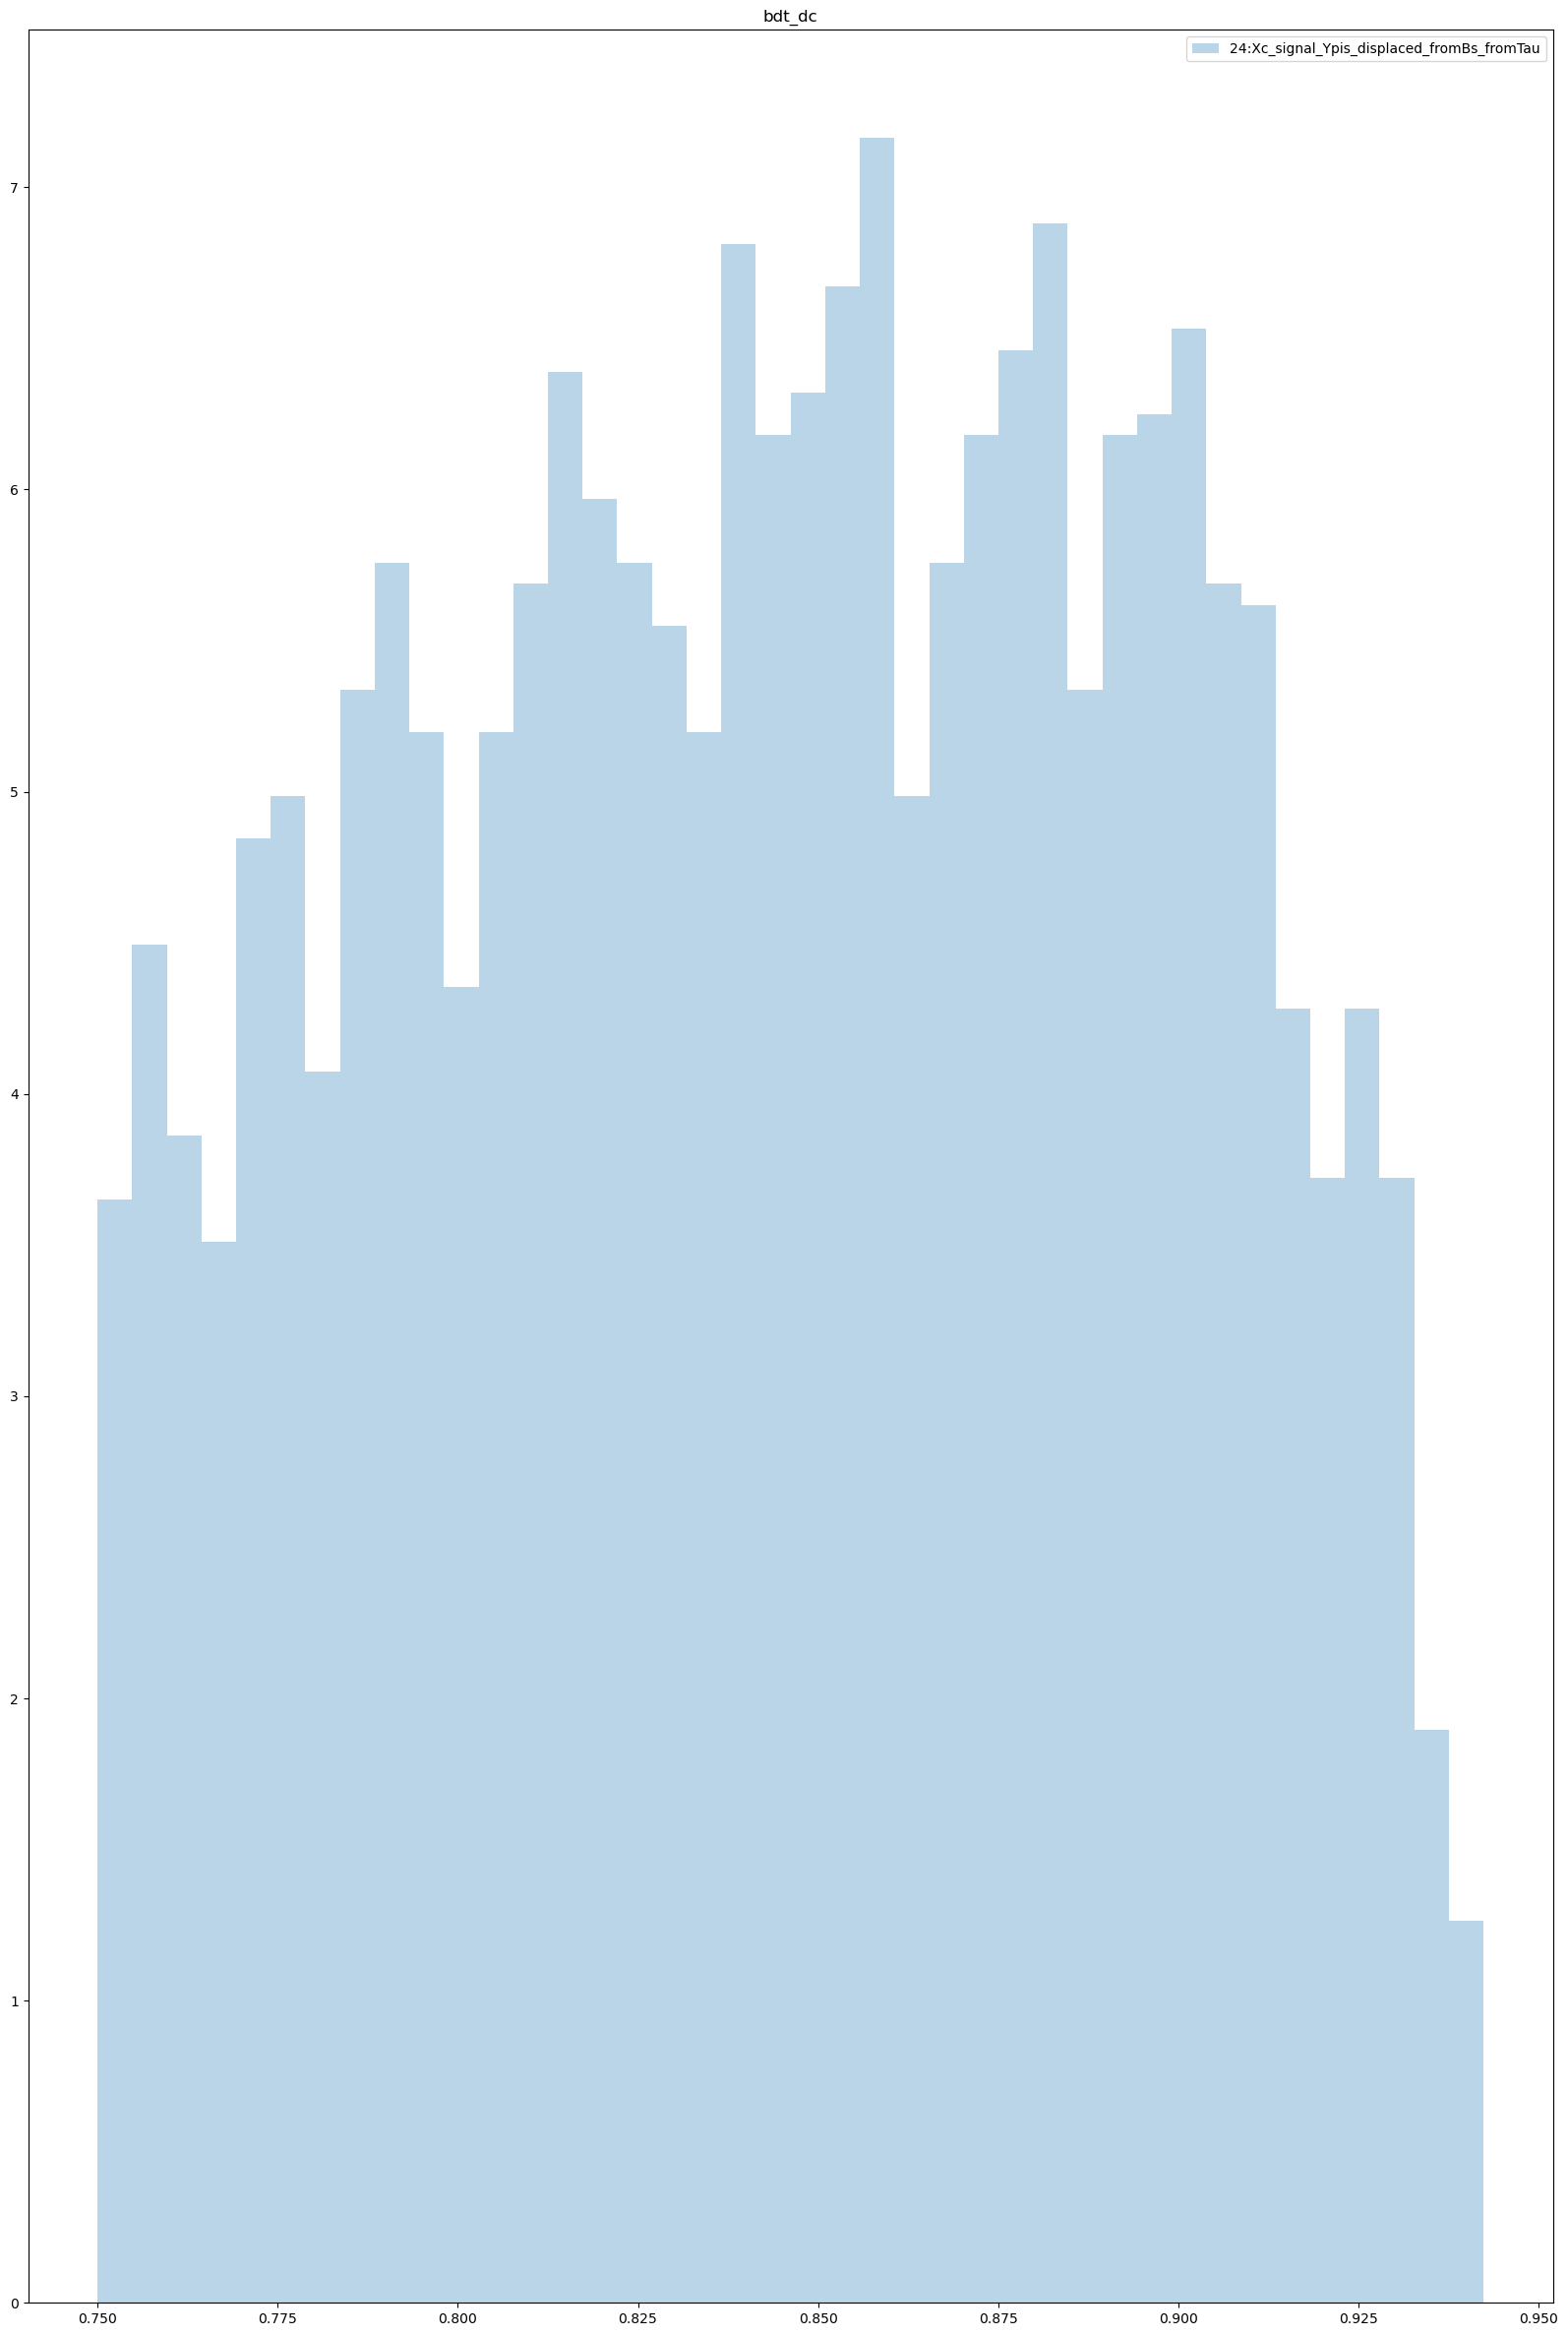

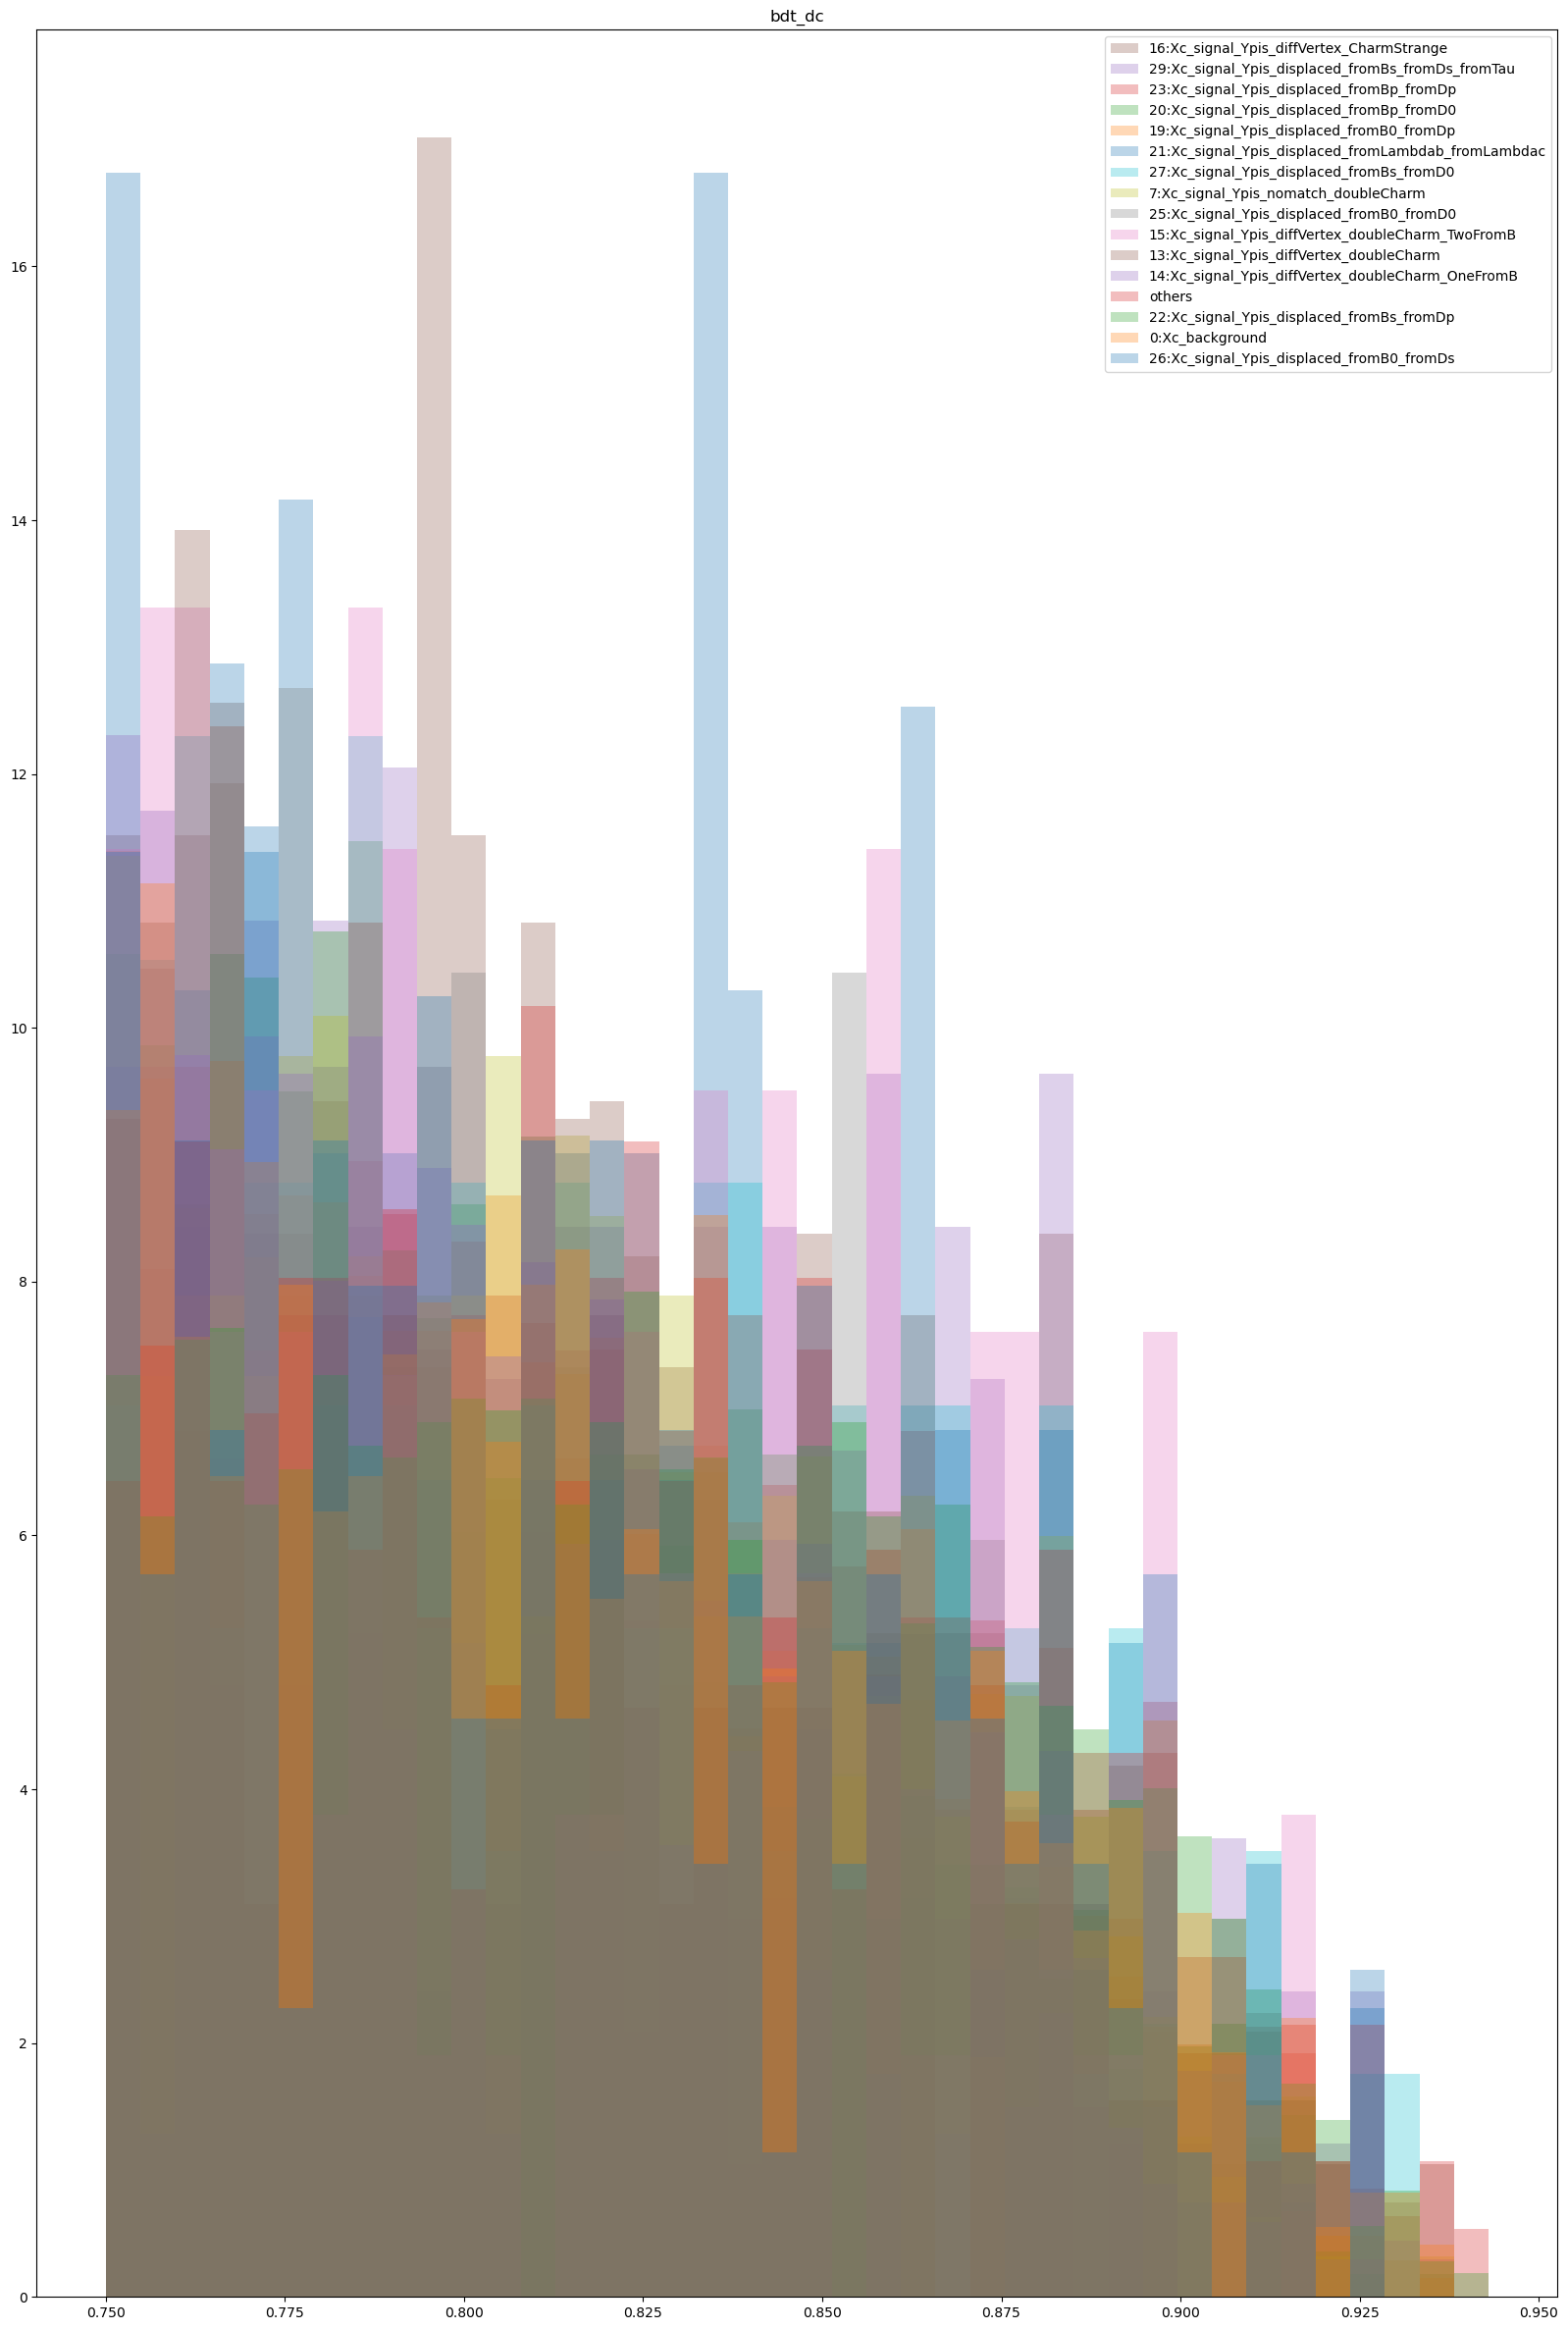

In [183]:
for c in clusters:
    plt.figure()
    plot_templates_categs(c, 'bdt_dc')